In [132]:
from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from pathlib import Path
import sys

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Project import ----
# Assumption: notebook lives in project_root/notebooks/ so parents[0] is project_root.
# If your notebook is deeper, change parents[...] accordingly.
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

# Global reproducibility for synthetic data generation
GLOBAL_SEED = 11
rng = np.random.default_rng(GLOBAL_SEED)


In [133]:
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    """
    2D Gaussian blob centered at (y0, x0) in Cartesian space.

    Important decision:
    - Cartesian coordinates use ordinary Euclidean distance.
    - No periodic wrapping is applied by default.
    """
    dy = y2d - float(y0)
    dx = x2d - float(x0)

    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def advect_centers(y0, x0, vy, vx, T):
    """
    Deterministic trajectory of the blob center in Cartesian space.

    Decision:
    - Constant velocity advection keeps the example interpretable.
    - You can later add time-varying velocity for a harder test.
    """
    centers = np.zeros((T, 2), dtype=float)
    y, x = float(y0), float(x0)

    for t in range(T):
        centers[t] = (y, x)
        y += float(vy)
        x += float(vx)

    return centers


def make_ar1_noise(shape, phi=0.8, sigma=0.1, rng=None, standardize=False):
    """
    Generate AR(1) noise in time independently at each grid point.

    Parameters
    ----------
    shape : tuple
        (T, NY, NX)
    phi : float
        AR(1) coefficient in time. Must satisfy |phi| < 1.
    sigma : float
        Innovation std.
    rng : np.random.Generator
    standardize : bool
        If True, standardize final field to mean 0 and std 1.

    Returns
    -------
    noise : np.ndarray
        AR(1) noise with shape (T, NY, NX)
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    # stationary initial condition
    noise[0] = rng.normal(
        0.0,
        sigma / np.sqrt(1.0 - phi**2 + 1e-12),
        size=(NY, NX)
    ).astype(np.float32)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise


from scipy.ndimage import gaussian_filter


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
    standardize=False
):
    """
    AR(1) in time with spatially smoothed innovations.

    Important decision:
    - In Cartesian toy experiments we use non-periodic boundaries,
      so smoothing uses mode='nearest'.
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(
        eps0,
        sigma=(smooth_sigma_y, smooth_sigma_x),
        mode="nearest"
    )

    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(
            eps,
            sigma=(smooth_sigma_y, smooth_sigma_x),
            mode="nearest"
        )
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise

In [134]:
def run_one_track(full_data, params, date_end):
    """
    Single Trace-ST run; returns centers (n_steps, 2) and parents.
    """
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )

    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)

    return centers, parents, out

In [135]:
# --- Time axis ---
T = 40
time = pd.date_range("2001-01-01", periods=T, freq="D")  # arbitrary, deterministic

# --- Spatial grid (Cartesian) ---
Y_MIN, Y_MAX = 0, 200
X_MIN, X_MAX = 0, 200

NY = 121
NX = 241

ys = np.linspace(Y_MIN, Y_MAX, NY)
xs = np.linspace(X_MIN, X_MAX, NX)

x2d, y2d = np.meshgrid(xs, ys)

print("Grid:", "NY=", NY, "NX=", NX, "x range=", (xs.min(), xs.max()))


# ------------------------------------------------------------
# Toy case: three parent blobs in the same A field
# Higher temporal resolution, same large-scale behavior
# ------------------------------------------------------------

import copy
import numpy as np

def linear_centers_to_event(event_y, event_x, vy, vx, T):
    """
    Build a linear trajectory whose final point is (event_y, event_x).
    """
    centers = np.zeros((T, 2), dtype=float)
    centers[-1] = (event_y, event_x)

    for t in range(T - 2, -1, -1):
        centers[t, 0] = centers[t + 1, 0] - vy
        centers[t, 1] = centers[t + 1, 1] - vx

    return centers


def bezier_centers(start, control1, control2, end, T):
    """
    Smooth curved trajectory using a cubic Bezier curve.
    All points are given as (y, x).
    """
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)

    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )

    return centers


# ------------------------------------------------------------
# Shared field parameters
# ------------------------------------------------------------
sig_y = 10.0
sig_x = 10.0
amp = 1.0

phi_A = 0.8
sigma_A = 0.1

beta_AB = 0.8
phi_B = 0.8
sigma_B = 0.1

clip_to_positive = True
clip_to_positive_B = True

# ------------------------------------------------------------
# Define the 3 true trajectories
# Everything moved 75 units left so all paths fit inside the domain
# ------------------------------------------------------------

track_specs = [
    dict(
        name="Track 1",
        event=(100.0, 50.0),
        centers=bezier_centers(
            start=(50.0, 10.0),
            control1=(70.0, 40.0),
            control2=(80.0, 55.0),
            end=(100.0, 50.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 2",
        event=(110.0, 105.0),
        centers=bezier_centers(
            start=(160.0, 60.0),
            control1=(150.0, 70.0),
            control2=(130.0, 130.0),
            end=(110.0, 105.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 3",
        event=(70.0, 100.0),
        centers=linear_centers_to_event(
            event_y=70.0,
            event_x=100.0,
            vy=(70.0 - 36.0) / (T - 1),
            vx=(100.0 - 168.0) / (T - 1),
            T=T,
        ),
        amp=1.0,
    ),
]

for spec in track_specs:
    c = spec["centers"]
    print(
        f'{spec["name"]}: start={tuple(np.round(c[0], 2))}, '
        f'end={tuple(np.round(c[-1], 2))}'
    )


# ------------------------------------------------------------
# Build clean parent field A as the sum of the 3 blobs
# ------------------------------------------------------------
A_clean = np.zeros((T, NY, NX), dtype=np.float32)

for spec in track_specs:
    centers = spec["centers"]
    amp_i = spec.get("amp", amp)

    for t in range(T):
        A_clean[t] += gaussian_blob(
            y2d,
            x2d,
            y0=centers[t, 0],
            x0=centers[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_i,
        ).astype(np.float32)

# ------------------------------------------------------------
# Add spatiotemporally autocorrelated noise to A
# ------------------------------------------------------------
rng_A = np.random.default_rng(GLOBAL_SEED)

noise_A = make_spatiotemporal_ar1_noise(
    A_clean.shape,
    phi=phi_A,
    sigma=sigma_A,
    rng=rng_A,
)

A = A_clean + noise_A

if clip_to_positive:
    A = np.clip(A, 0.0, None)

# ------------------------------------------------------------
# Build child field B from lagged A plus its own persistent noise
# ------------------------------------------------------------
rng_B = np.random.default_rng(GLOBAL_SEED + 1)

noise_B = make_spatiotemporal_ar1_noise(
    A.shape,
    phi=0.8,
    sigma=sigma_B,
    rng=rng_B,
)

B = np.zeros_like(A, dtype=np.float32)
B[0] = noise_B[0]

for t in range(1, T):
    B[t] = phi_B * B[t - 1] + beta_AB * A[t - 1] + noise_B[t]

if clip_to_positive_B:
    B = np.clip(B, 0.0, None)

print(
    "Raw Corr(A[t-1], B[t]) =",
    float(np.corrcoef(A[:-1].ravel(), B[1:].ravel())[0, 1])
)

Grid: NY= 121 NX= 241 x range= (0.0, 200.0)
Track 1: start=(50.0, 10.0), end=(100.0, 50.0)
Track 2: start=(160.0, 60.0), end=(110.0, 105.0)
Track 3: start=(36.0, 168.0), end=(70.0, 100.0)
Raw Corr(A[t-1], B[t]) = 0.8822109442587748


In [136]:

full_data_A = xr.DataArray(
    A[:, None, :, :].astype(np.float32),
    dims=("time", "var", "y", "x"),
    coords={"time": time, "var": ["A"], "y": ys, "x": xs},
    name="synthetic",
)
full_data_B = xr.DataArray(
    B[:, None, :, :].astype(np.float32),
    dims=("time", "var", "y", "x"),
    coords={"time": time, "var": ["B"], "y": ys, "x": xs},
    name="synthetic",
)

full_data_case1 = xr.concat([full_data_A, full_data_B], dim="var")
full_data_case1 = full_data_case1.rename({"y": "lat", "x": "lon"})
date_end = str(time[-1].date())

In [137]:
# --- core ---
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- plotting style ---
plt.rcParams["figure.dpi"] = 120

# --- paths ---
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/univariate_v0")  # CHANGE if needed

# -----------------------------------------------------------------------------
# helpers
# -----------------------------------------------------------------------------
def _load_jsonl(path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def _maybe_parse_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return None
        try:
            return json.loads(x)
        except Exception:
            try:
                return ast.literal_eval(x)
            except Exception:
                return x
    return x

# -----------------------------------------------------------------------------
# load outputs
# -----------------------------------------------------------------------------
jobs_jsonl = OUTDIR / "results_jobs.jsonl"
tracks_jsonl = OUTDIR / "results_tracks.jsonl"

jobs_csv = OUTDIR / "results_jobs_final.csv"
if not jobs_csv.exists():
    jobs_csv = OUTDIR / "results_jobs_snapshot.csv"

tracks_csv = OUTDIR / "results_tracks_final.csv"
if not tracks_csv.exists():
    tracks_csv = OUTDIR / "results_tracks_snapshot.csv"

# Prefer JSONL for tracks because it preserves nested trajectory lists cleanly
if jobs_jsonl.exists():
    jobs_raw = _load_jsonl(jobs_jsonl)
else:
    jobs_raw = pd.read_csv(jobs_csv)

if tracks_jsonl.exists():
    tracks_raw = _load_jsonl(tracks_jsonl)
else:
    tracks_raw = pd.read_csv(tracks_csv)
    if "centers_raw" in tracks_raw.columns:
        tracks_raw["centers_raw"] = tracks_raw["centers_raw"].apply(_maybe_parse_list)
    if "parents_raw" in tracks_raw.columns:
        tracks_raw["parents_raw"] = tracks_raw["parents_raw"].apply(_maybe_parse_list)

# -----------------------------------------------------------------------------
# standardize names / expected columns
# -----------------------------------------------------------------------------
param_cols = [
    "timewindow", "box_size", "radius", "eps_dbscan", "min_samples_dbscan",
    "score_mode", "winner_summary", "alpha", "prefer_sign", "prob_rule",
    "beta_softmax", "lambda_a", "l1_ratio", "dependence_threshold",
    "max_iter", "fit_intercept", "refit_ridge", "ridge_alpha",
    "pc_alpha", "graph_p_threshold", "cond_ind_test_name", "fdr_method"
]

track_metric_cols = [
    "raw_len", "failed", "mean_distance", "origin_distance", "event_distance",
    "path_length", "net_displacement", "mean_step", "stagnant_frac",
    "parent2_frac"
]

for c in param_cols:
    if c not in jobs_raw.columns:
        jobs_raw[c] = np.nan
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

# if some older run still had track_id, standardize to track_idx
if "track_id" in tracks_raw.columns and "track_idx" not in tracks_raw.columns:
    tracks_raw = tracks_raw.rename(columns={"track_id": "track_idx"})

# -----------------------------------------------------------------------------
# df_long
# -----------------------------------------------------------------------------
required_df_long = [
    "method", "trial_id", "track_name", "track_idx", "event_y", "event_x",
    "raw_len", "failed", "mean_distance", "origin_distance",
    "event_distance", "path_length", "net_displacement", "mean_step",
    "stagnant_frac", "parent2_frac", "elapsed_sec"
] + param_cols

for c in required_df_long:
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

df_long = tracks_raw[required_df_long].copy()

# -----------------------------------------------------------------------------
# df_trial
# -----------------------------------------------------------------------------
job_base = jobs_raw.copy()

rename_job_to_old = {
    "score_mean_distance": "mean_distance",
    "score_origin_distance": "mean_origin_distance",
    "score_event_distance": "mean_event_distance",
    "score_path_length": "mean_path_length",
    "score_net_displacement": "mean_net_displacement",
    "score_stagnant_frac": "mean_stagnant_frac",
    "score_parent2_frac": "mean_parent2_frac",
}
for src, dst in rename_job_to_old.items():
    if src in job_base.columns:
        job_base = job_base.rename(columns={src: dst})

# keep only successful runs, like old analyses usually expect
if "ok" in job_base.columns:
    job_base = job_base[job_base["ok"] == 1].copy()

agg = (
    tracks_raw.groupby(["method", "trial_id"], as_index=False)
    .agg(
        n_tracks=("track_idx", "size"),
        n_failed=("failed", "sum"),
        mean_raw_len=("raw_len", "mean"),
        min_raw_len=("raw_len", "min"),
        mean_distance=("mean_distance", "mean"),
        max_distance=("mean_distance", "max"),
        mean_origin_distance=("origin_distance", "mean"),
        mean_event_distance=("event_distance", "mean"),
        mean_path_length=("path_length", "mean"),
        mean_net_displacement=("net_displacement", "mean"),
        mean_step=("mean_step", "mean"),
        mean_stagnant_frac=("stagnant_frac", "mean"),
        mean_parent2_frac=("parent2_frac", "mean"),
    )
)

wide_parts = []
for tidx in [1, 2, 3]:
    tmp = tracks_raw[tracks_raw["track_idx"] == tidx][["method", "trial_id"] + track_metric_cols].copy()
    tmp = tmp.rename(columns={m: f"track{tidx}_{m}" for m in track_metric_cols})
    wide_parts.append(tmp)

wide = wide_parts[0]
for tmp in wide_parts[1:]:
    wide = wide.merge(tmp, on=["method", "trial_id"], how="outer")

job_keep_cols = ["method", "trial_id", "elapsed_sec"] + param_cols
for c in job_keep_cols:
    if c not in job_base.columns:
        job_base[c] = np.nan

job_base = job_base[job_keep_cols].drop_duplicates(subset=["method", "trial_id"]).copy()

df_trial = (
    job_base
    .merge(agg, on=["method", "trial_id"], how="left")
    .merge(wide, on=["method", "trial_id"], how="left")
)

required_df_trial = [
    "method", "trial_id", "n_tracks", "n_failed", "mean_raw_len",
    "min_raw_len", "mean_distance", "max_distance", "mean_origin_distance",
    "mean_event_distance", "mean_path_length", "mean_net_displacement",
    "mean_step", "mean_stagnant_frac", "mean_parent2_frac", "elapsed_sec"
] + param_cols + [
    "track1_raw_len", "track1_failed", "track1_mean_distance",
    "track1_origin_distance", "track1_event_distance", "track1_path_length",
    "track1_net_displacement", "track1_mean_step", "track1_stagnant_frac",
    "track1_parent2_frac",
    "track2_raw_len", "track2_failed", "track2_mean_distance",
    "track2_origin_distance", "track2_event_distance", "track2_path_length",
    "track2_net_displacement", "track2_mean_step", "track2_stagnant_frac",
    "track2_parent2_frac",
    "track3_raw_len", "track3_failed", "track3_mean_distance",
    "track3_origin_distance", "track3_event_distance", "track3_path_length",
    "track3_net_displacement", "track3_mean_step", "track3_stagnant_frac",
    "track3_parent2_frac",
]

for c in required_df_trial:
    if c not in df_trial.columns:
        df_trial[c] = np.nan

df_trial = df_trial[required_df_trial].copy()

# optional: sort trials the same way the script ranks them
sort_cols = [c for c in ["mean_distance", "mean_origin_distance", "mean_event_distance"] if c in df_trial.columns]
if sort_cols:
    df_trial = df_trial.sort_values(sort_cols, ascending=True).reset_index(drop=True)

# -----------------------------------------------------------------------------
# df_traj
# -----------------------------------------------------------------------------
required_df_traj = [
    "method", "trial_id", "track_name", "track_idx", "event_y", "event_x",
    "centers_raw", "parents_raw", "elapsed_sec"
] + param_cols

for c in required_df_traj:
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

df_traj = tracks_raw[required_df_traj].copy()

# -----------------------------------------------------------------------------
# report
# -----------------------------------------------------------------------------
print("Loaded:")
print("df_long :", df_long.shape)
print("df_trial:", df_trial.shape)
print("df_traj :", df_traj.shape)

print("\ndf_long keys():")
print(df_long.keys())

print("\ndf_trial keys():")
print(df_trial.keys())

print("\ndf_traj keys():")
print(df_traj.keys())

df_trial.head()

Loaded:
df_long : (9000, 39)
df_trial: (3000, 68)
df_traj : (9000, 31)

df_long keys():
Index(['method', 'trial_id', 'track_name', 'track_idx', 'event_y', 'event_x',
       'raw_len', 'failed', 'mean_distance', 'origin_distance',
       'event_distance', 'path_length', 'net_displacement', 'mean_step',
       'stagnant_frac', 'parent2_frac', 'elapsed_sec', 'timewindow',
       'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax',
       'lambda_a', 'l1_ratio', 'dependence_threshold', 'max_iter',
       'fit_intercept', 'refit_ridge', 'ridge_alpha', 'pc_alpha',
       'graph_p_threshold', 'cond_ind_test_name', 'fdr_method'],
      dtype='object')

df_trial keys():
Index(['method', 'trial_id', 'n_tracks', 'n_failed', 'mean_raw_len',
       'min_raw_len', 'mean_distance', 'max_distance', 'mean_origin_distance',
       'mean_event_distance', 'mean_path_length', 'mean_net_displacement',
       'me

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_raw_len,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac
0,dynotears,138,3,0,31.0,31,2.305204,3.373177,2.846643,0.0,...,31,0,3.373177,4.747485,0.0,63.348962,62.161642,2.111632,0.0,0.967742
1,dynotears,539,3,0,31.0,31,2.318836,3.259864,3.033963,0.0,...,31,0,1.206919,1.236679,0.0,61.580931,58.447098,2.052698,0.0,0.967742
2,dynotears,115,3,0,31.0,31,2.352662,3.252418,3.292413,0.0,...,31,0,1.702950,1.264148,0.0,62.028656,57.561838,2.067622,0.0,0.967742
3,dynotears,924,3,0,31.0,31,2.412567,3.454657,3.013619,0.0,...,31,0,1.205330,2.480147,0.0,60.228430,56.998498,2.007614,0.0,0.967742
4,dynotears,512,3,0,31.0,31,2.432494,3.194051,3.588090,0.0,...,31,0,1.667613,2.982296,0.0,61.567481,57.389923,2.052249,0.0,0.967742


In [138]:
# remove potential error rows
df_trial = df_trial[df_trial["track1_failed"].notna()].copy()

# enforce numeric
numeric_cols = [
    "mean_distance",
    "mean_raw_len",
    "mean_parent2_frac",
    "mean_stagnant_frac",
    "mean_step",
]
for c in numeric_cols:
    df_trial[c] = pd.to_numeric(df_trial[c], errors="coerce")

# sanity
print(df_trial["method"].value_counts())

dynotears    1000
granger      1000
pcmci        1000
Name: method, dtype: int64


In [186]:
def define_internal_valid(df):
    """
    INTERNAL validity:
    - no failure
    - not too short
    - not stagnant
    - non-trivial movement
    """

    cond = (
        (df["min_raw_len"] == 31)#&
        # (df["n_failed"] == 0)
        # (df["mean_stagnant_frac"] == 0)#&
        # (df["mean_net_displacement"] > 25)
    )

    return cond

In [187]:
df_trial["internal_valid"] = define_internal_valid(df_trial)

print("\nInternal validity fraction:")
print(df_trial["internal_valid"].value_counts(normalize=True))


Internal validity fraction:
True     0.841667
False    0.158333
Name: internal_valid, dtype: float64


In [188]:
keys_params = ['method','elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha','pc_alpha', 'graph_p_threshold',
       'cond_ind_test_name', 'fdr_method']

In [189]:
valid_temp = df_trial[(df_trial['method']=='granger')&(df_trial['internal_valid']==True)][keys_params[:-4]]
invalid_temp = df_trial[(df_trial['method']=='granger')&(df_trial['internal_valid']==False)][keys_params[:-4]]

In [190]:
valid_temp

,method,elapsed_sec,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,prefer_sign,prob_rule,beta_softmax,lambda_a,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha
16,granger,8.415752,3d,15,2,0.25,2,sum,mean,4.0,both,softmax,1.0,0.001196,0.235547,1.000000e-07,100000.0,False,False,0.01
26,granger,7.891875,2d,15,2,0.10,2,sum,mean,4.0,both,softmax,2.0,0.003458,0.102971,1.000000e-07,100000.0,False,False,0.01
28,granger,24.665527,4d,15,2,0.20,2,mean,mean,0.5,both,softmax,0.0,0.007043,0.000423,1.000000e-07,100000.0,False,False,0.01
29,granger,35.438475,3d,15,2,0.20,2,sum,mean,2.0,both,softmax,64.0,0.004162,0.000106,1.000000e-07,100000.0,False,False,0.01
33,granger,3.937873,3d,15,2,0.10,2,sum,mean,8.0,both,linear,4.0,0.107288,0.952408,1.000000e-07,100000.0,False,False,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2808,granger,36.034357,4d,30,3,0.25,2,mean,mean,0.5,both,softmax,8.0,0.002286,0.005923,1.000000e-07,100000.0,False,False,0.01
2810,granger,163.658588,4d,30,3,0.20,2,mean,mean,16.0,both,softmax,8.0,0.002260,0.000171,1.000000e-07,100000.0,False,False,0.01
2816,granger,13.686352,2d,15,3,0.10,2,mean,mean,8.0,both,linear,0.5,0.001030,0.027026,1.000000e-07,100000.0,False,False,0.01
2826,granger,22.120974,3d,15,3,0.25,2,mean,mean,0.5,both,softmax,2.0,0.002004,0.000509,1.000000e-07,100000.0,False,False,0.01


In [194]:
df_trial[(df_trial['method']=='granger')&(df_trial['internal_valid']==True)]

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,internal_valid
16,granger,467,3,0,31.0,31,2.805872,3.022833,3.943691,0.0,...,0,3.022833,6.572593,0.0,64.397672,56.655474,2.146589,0.000000,0.000000,True
26,granger,840,3,0,31.0,31,2.942131,4.377459,2.931645,0.0,...,0,1.637604,5.495149,0.0,61.626059,52.989164,2.054202,0.000000,0.000000,True
28,granger,435,3,0,31.0,31,2.968692,4.328748,4.086856,0.0,...,0,2.926911,3.836632,0.0,63.908971,61.666548,2.130299,0.033333,0.000000,True
29,granger,409,3,0,31.0,31,2.976747,3.445203,5.249756,0.0,...,0,3.445203,5.640157,0.0,61.301584,52.989582,2.043386,0.000000,0.000000,True
33,granger,304,3,0,31.0,31,3.024341,3.978146,3.334589,0.0,...,0,2.173969,2.404363,0.0,59.322724,56.492657,1.977424,0.066667,0.967742,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2808,granger,16,3,0,31.0,31,24.641839,28.737926,50.827479,0.0,...,0,28.737926,56.824939,0.0,3.950714,3.950714,0.131690,0.933333,0.000000,True
2810,granger,191,3,0,31.0,31,24.654551,28.776064,50.865230,0.0,...,0,28.776064,56.938192,0.0,3.662447,3.662447,0.122082,0.933333,0.000000,True
2816,granger,935,3,0,31.0,31,24.730325,28.613476,52.115009,0.0,...,0,28.613476,57.351506,0.0,7.211103,5.099020,0.240370,0.933333,0.935484,True
2826,granger,715,3,0,31.0,31,24.802608,32.241420,50.852222,0.0,...,0,32.241420,61.618767,0.0,5.999050,3.168071,0.199968,0.933333,0.935484,True


In [191]:
df_valid = df_trial[df_trial["internal_valid"]].copy()

print("Valid runs:", len(df_valid))

Valid runs: 2525


In [166]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def add_boxes(ax, centers, box_size, color, alpha=0.14, lw=1.1, zorder=2):
    half = box_size / 2.0
    for yc, xc in centers:
        rect = Rectangle(
            (xc - half, yc - half),
            box_size,
            box_size,
            fill=False,
            edgecolor=color,
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)


def _to_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=float)


def plot_trial_trajectories(
    trial_row,
    df_search_traj,
    track_specs,
    A,
    xs,
    ys,
    T,
    contour_level=0.6,
    extent=(0, 200, 0, 200),
    figsize=(10.5, 8),
    n_truth_plot=24,
    box_stride=2,
):
    """
    Plot the 3 synthetic truth trajectories and the recovered trajectories
    for one selected trial row from df_search_trial.

    Parameters
    ----------
    trial_row : pd.Series
        One row from df_search_trial, e.g. df_search_trial.iloc[0]
    df_search_traj : pd.DataFrame
        Trajectory archive with raw centers/parents
    track_specs : list of dict
        Synthetic truth definitions
    A : np.ndarray
        Parent field used for contours, shape (T, NY, NX)
    xs, ys : 1D arrays
        Grid coordinates
    T : int
        Number of timesteps
    n_truth_plot : int
        Number of truth snapshots/contours to display
    box_stride : int
        Plot every `box_stride`-th box to reduce clutter
    """
    method = trial_row["method"]
    trial_id = trial_row["trial_id"]
    box_size = float(trial_row["box_size"])

    sub = df_search_traj[
        (df_search_traj["method"] == method) &
        (df_search_traj["trial_id"] == trial_id)
    ].copy()

    if len(sub) == 0:
        raise ValueError(f"No trajectories found for method={method}, trial_id={trial_id}")

    # determine max recovered trajectory length across the 3 tracks
    lengths = []
    for _, r in sub.iterrows():
        centers = _to_array(r["centers_raw"])
        lengths.append(len(centers))
    n_back = max(lengths) if len(lengths) > 0 else 1

    truth_idx = np.linspace(T - n_back, T - 1, min(n_truth_plot, n_back), dtype=int)
    truth_idx = np.unique(truth_idx)

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------
    # 1) contours of A
    # --------------------------------------------------
    for t in truth_idx:
        ax.contour(
            xs,
            ys,
            A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.6,
            zorder=1,
        )

    # --------------------------------------------------
    # 2) true trajectories + event markers
    # --------------------------------------------------
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        event_y, event_x = spec["event"]

        ax.plot(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            "--",
            color="black",
            linewidth=1.9,
            zorder=4,
            label="True trajectory" if k == 1 else None,
        )

        ax.scatter(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            s=18,
            color="black",
            zorder=5,
        )

        ax.plot(
            event_x,
            event_y,
            marker="X",
            markersize=12,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )

        ax.text(
            event_x + 2.5,
            event_y + 2.5,
            f"{k}",
            fontsize=10,
            weight="bold",
            color="black",
            zorder=11,
        )

    # --------------------------------------------------
    # 3) recovered trajectories for this trial
    # --------------------------------------------------
    color = {
        "granger": "tab:blue",
        "pcmci": "tab:green",
        "dynotears": "tab:orange",
    }.get(method, "tab:purple")

    label_map = {
        "granger": "Granger",
        "pcmci": "PCMCI",
        "dynotears": "Dynotears",
    }
    method_label = label_map.get(method, str(method))

    shown_label = False

    for spec in track_specs:
        r = sub[sub["track_name"] == spec["name"]]
        if len(r) == 0:
            continue

        r = r.iloc[0]
        centers = _to_array(r["centers_raw"])

        centers_for_boxes = centers[::box_stride] if box_stride > 1 else centers

        add_boxes(
            ax,
            centers_for_boxes,
            box_size=box_size,
            color=color,
            alpha=0.14,
            lw=1.0,
            zorder=2,
        )

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color=color,
            linewidth=2.0,
            alpha=0.55,
            zorder=6,
            label=method_label if not shown_label else None,
        )

        ax.plot(
            centers[0, 1],
            centers[0, 0],
            marker="s",
            markersize=7,
            color=color,
            zorder=7,
        )

        ax.plot(
            centers[-1, 1],
            centers[-1, 0],
            marker="*",
            markersize=12,
            color=color,
            zorder=8,
        )

        shown_label = True

    # --------------------------------------------------
    # 4) formatting
    # --------------------------------------------------
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.22, linewidth=0.5)

    title = (
        f"TraCE-ST trajectories | method={method}, trial_id={trial_id}\n"
        f"box={trial_row['box_size']}, radius={trial_row['radius']}, "
        f"timewindow={trial_row['timewindow']}, eps={trial_row['eps_dbscan']}"
    )
    ax.set_title(title, fontsize=12)

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

In [167]:
best_runs = (
    df_valid.sort_values("mean_origin_distance")
    .groupby("method")
    .head(1)
)

best_runs

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,internal_valid
55,dynotears,615,3,0,31.0,31,3.210492,3.506937,1.836053,0.0,...,0,2.893226,1.869695,0.0,60.139749,56.956202,2.004658,0.000000,0.967742,True
299,granger,594,3,0,31.0,31,4.730066,5.522549,2.429939,0.0,...,0,5.040969,2.579268,0.0,82.202712,58.364482,2.740090,0.000000,0.096774,True
1468,pcmci,736,3,0,31.0,31,12.270435,12.942248,14.148454,0.0,...,0,11.315296,12.773469,0.0,64.579790,46.442952,2.152660,0.066667,0.000000,True


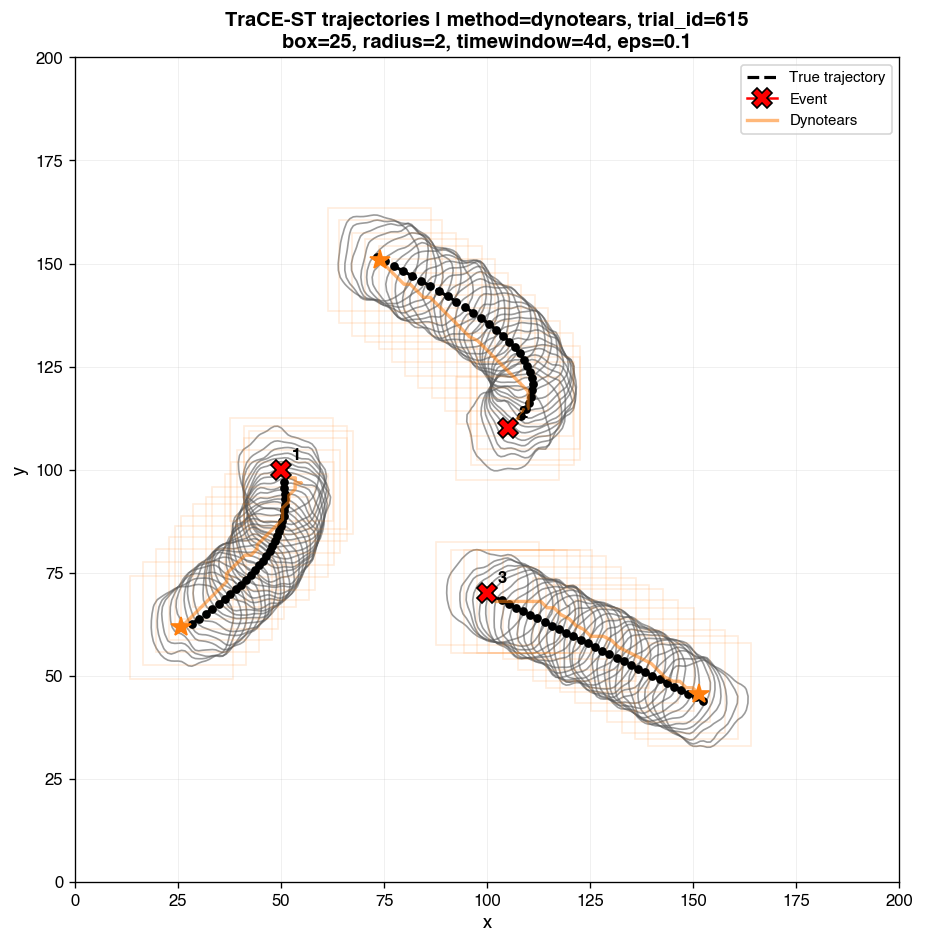

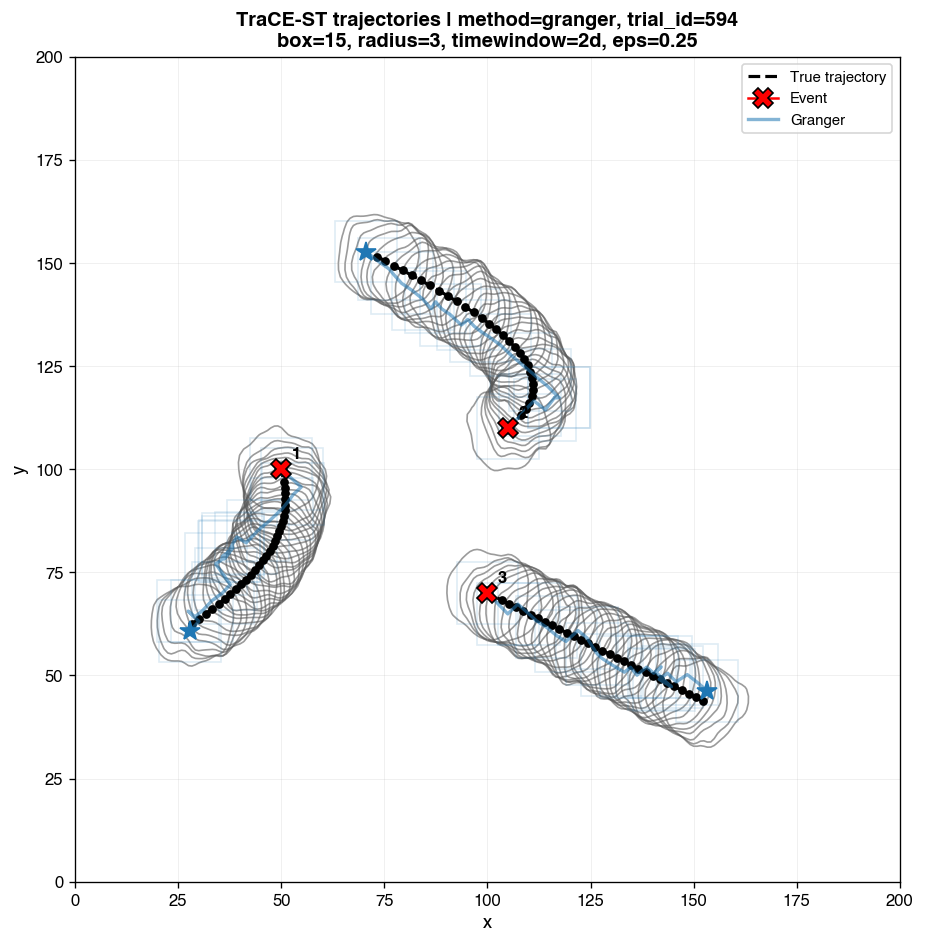

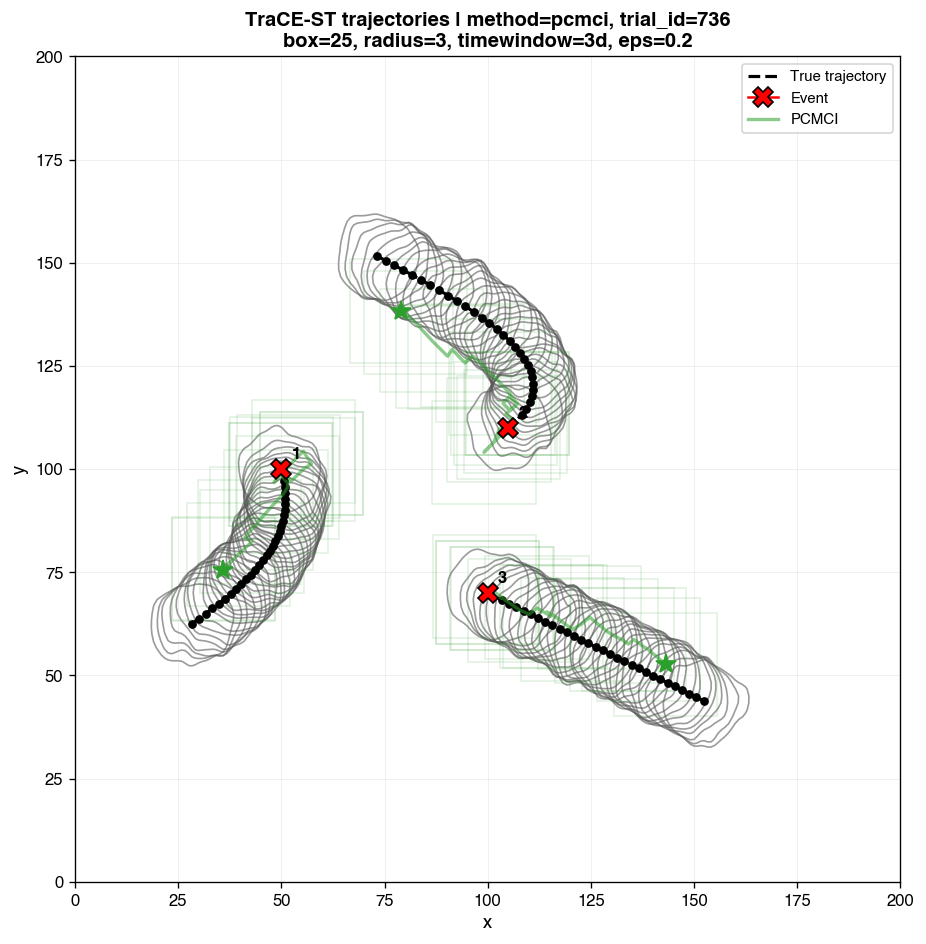

In [168]:
for _, row in best_runs.iterrows():
    plot_trial_trajectories(
        trial_row=row,
        df_search_traj=df_traj,
        track_specs=track_specs,   # MUST exist in this notebook
        A=A,                       # MUST exist
        xs=xs,
        ys=ys,
        T=T,
        n_truth_plot=30
)

In [169]:
import ast
import numpy as np
import matplotlib.pyplot as plt


def _to_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=float)


def _to_int_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=int)


def _pad_or_truncate_centers(centers, target_len):
    centers = np.asarray(centers, dtype=float)
    if len(centers) == 0:
        return None
    if len(centers) < target_len:
        centers = np.vstack([
            centers,
            np.repeat(centers[-1:, :], target_len - len(centers), axis=0)
        ])
    else:
        centers = centers[:target_len]
    return centers


def plot_valid_trajectories_ensemble(
    df_valid_method,
    df_search_traj,
    track_specs,
    A,
    xs,
    ys,
    T,
    method=None,
    contour_level=0.6,
    extent=(0, 200, 0, 200),
    figsize=(10.5, 8),
    traj_alpha=0.10,
    traj_lw=1.1,
    mean_lw=3.0,
    show_mean=True,
    max_runs=None,
    n_truth_plot=31,
    target_len=31,
    show_parent2=True,
    parent2_size=18,
    parent2_alpha=0.65,
):
    """
    Plot all internally valid trajectories for one method as an ensemble.
    """

    dfv = df_valid_method.copy()

    if method is None:
        methods = dfv["method"].dropna().unique()
        if len(methods) != 1:
            raise ValueError("Please pass `method=` explicitly if df_valid_method has multiple methods.")
        method = methods[0]

    dfv = dfv[dfv["method"] == method].copy()
    if len(dfv) == 0:
        raise ValueError(f"No valid runs found for method={method}")

    if max_runs is not None and len(dfv) > max_runs:
        dfv = dfv.iloc[:max_runs].copy()

    color = {
        "granger": "tab:blue",
        "pcmci": "tab:green",
        "dynotears": "tab:orange",
    }.get(method, "tab:purple")

    label_map = {
        "granger": "Elastic-Net",
        "pcmci": "PCMCI",
        "dynotears": "DYNOTEARS",
    }
    method_label = label_map.get(method, str(method))

    trial_ids = set(dfv["trial_id"].tolist())

    sub_traj = df_search_traj[
        (df_search_traj["method"] == method) &
        (df_search_traj["trial_id"].isin(trial_ids))
    ].copy()

    if len(sub_traj) == 0:
        raise ValueError(f"No trajectories found for method={method} and selected valid runs")

    lengths = []
    for _, r in sub_traj.iterrows():
        centers = _to_array(r["centers_raw"])
        lengths.append(len(centers))
    n_back = max(lengths) if len(lengths) > 0 else 1

    truth_idx = np.linspace(T - n_back, T - 1, min(n_truth_plot, n_back), dtype=int)
    truth_idx = np.unique(truth_idx)

    fig, ax = plt.subplots(figsize=figsize)

    # 1) contours of A
    for t in truth_idx:
        ax.contour(
            xs,
            ys,
            A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.6,
            zorder=1,
        )

    # 2) true trajectories + event markers
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        event_y, event_x = spec["event"]

        ax.plot(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            "--",
            color="black",
            linewidth=2.0,
            zorder=5,
            label="True trajectory" if k == 1 else None,
        )

        ax.scatter(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            s=16,
            color="black",
            zorder=6,
        )

        ax.plot(
            event_x,
            event_y,
            marker="X",
            markersize=12,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )

        ax.text(
            event_x + 2.5,
            event_y + 2.5,
            f"{k}",
            fontsize=10,
            weight="bold",
            color="black",
            zorder=11,
        )

    # 3) all valid recovered trajectories
    shown_label = False
    shown_parent2_label = False

    for spec in track_specs:
        track_name = spec["name"]
        sub_track = sub_traj[sub_traj["track_name"] == track_name].copy()

        if len(sub_track) == 0:
            continue

        aligned_centers = []

        for _, r in sub_track.iterrows():
            centers = _to_array(r["centers_raw"])
            if len(centers) == 0:
                continue

            ax.plot(
                centers[:, 1],
                centers[:, 0],
                "-",
                color=color,
                linewidth=traj_lw,
                alpha=traj_alpha,
                zorder=3,
                label=method_label if not shown_label else None,
            )

            ax.plot(
                centers[0, 1],
                centers[0, 0],
                marker="s",
                markersize=4.5,
                color=color,
                alpha=0.25,
                zorder=4,
            )

            ax.plot(
                centers[-1, 1],
                centers[-1, 0],
                marker="*",
                markersize=7,
                color=color,
                alpha=0.35,
                zorder=4,
            )

            if show_parent2 and "parents_raw" in r and r["parents_raw"] is not None:
                parents = _to_int_array(r["parents_raw"])

                n = min(len(centers), len(parents))
                if n > 0:
                    centers_p = centers[:n]
                    parents_p = parents[:n]
                    mask2 = parents_p == 2

                    if np.any(mask2):
                        ax.scatter(
                            centers_p[mask2, 1],
                            centers_p[mask2, 0],
                            s=parent2_size,
                            color="red",
                            alpha=parent2_alpha,
                            zorder=7,
                            label="Parent = 2" if not shown_parent2_label else None,
                        )
                        shown_parent2_label = True

            aligned = _pad_or_truncate_centers(centers, target_len)
            if aligned is not None:
                aligned_centers.append(aligned)

            shown_label = True

    # 4) formatting
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.22, linewidth=0.5)

    ax.set_title(
        f"Internally valid {method_label} trajectories (n={len(dfv)})",
        fontsize=12
    )

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

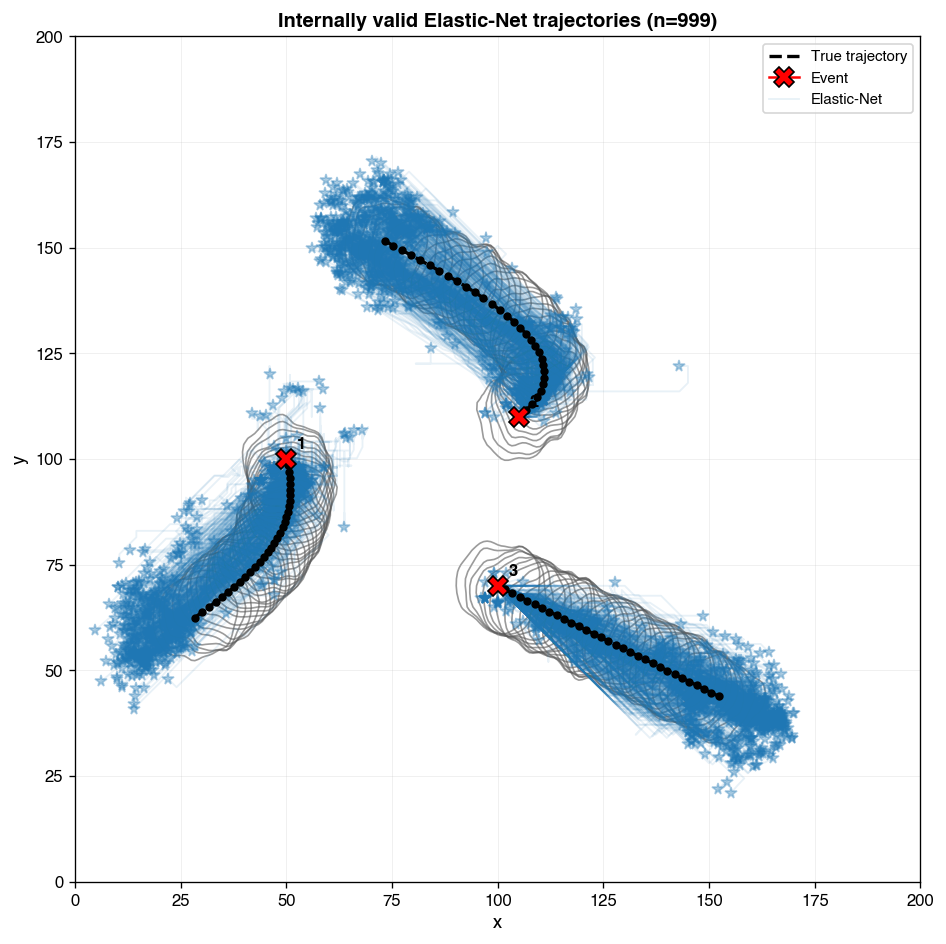

In [170]:
plot_valid_trajectories_ensemble(
    df_valid_method=df_valid[df_valid["method"] == "granger"],
    df_search_traj=df_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    method="granger",
    show_parent2=False,
    parent2_alpha=0.01,
    parent2_size=10
)

# build stencils

In [171]:
# =========================================================
# Build params_case1_by_method_and_track from newest results
# =========================================================

from tigramite.independence_tests.parcorr import ParCorr
try:
    from tigramite.independence_tests.robust_parcorr import RobustParCorr
except Exception:
    RobustParCorr = ParCorr  # safe fallback if robust version is unavailable

# ---------------------------------------------------------
# 1. choose the best row per method and per track
# ---------------------------------------------------------
# select best row per method and track using minimum origin distance
case_metric_map = {
    "Track 1": "track1_origin_distance",
    "Track 2": "track2_origin_distance",
    "Track 3": "track3_origin_distance",
}

best_rows_case1 = {
    "granger": {},
    "pcmci": {},
    "dynotears": {},
}

for method in best_rows_case1:
    sub_method = df_valid[df_valid["method"] == method].copy()

    for track_name, metric_col in case_metric_map.items():
        sub_track = (
            sub_method
            .dropna(subset=[metric_col])
            .sort_values(metric_col, ascending=True)
            .copy()
        )

        if len(sub_track) == 0:
            raise ValueError(
                f"No valid rows found for method={method}, "
                f"track={track_name}, metric={metric_col}"
            )

        best_rows_case1[method][track_name] = sub_track.iloc[0]

print("Best rows selected per method and track:")
for method in best_rows_case1:
    for track_name, metric_col in case_metric_map.items():
        row = best_rows_case1[method][track_name]
        print(f"{method:10s} | {track_name:7s} | {metric_col}={row[metric_col]:.4f}")
        
# ---------------------------------------------------------
# 2. parameter builders (same logic as Fig2_ToyCases_v3, adapted to new tables)
# ---------------------------------------------------------
def _safe_int(x, default):
    return default if pd.isna(x) else int(x)

def _safe_float(x, default):
    return default if pd.isna(x) else float(x)

def _safe_str(x, default):
    return default if pd.isna(x) else str(x)

def _safe_bool(x, default):
    return default if pd.isna(x) else bool(x)

def build_granger_case1_params(best_row):
    return dict(
        timeres="1d",
        spaceres=1,
        box_size=_safe_int(best_row["box_size"], 16),
        radius=_safe_int(best_row["radius"], 3),
        starting_lat=None,
        starting_lon=None,
        timewindow=_safe_str(best_row["timewindow"], "4d"),
        child_of_interest=1,
        n_steps_time=15,
        averaging_winners=True,
        snap_to_grid=False,
        montecarlo=False,
        beta_softmax=3.5 if _safe_str(best_row.get("prob_rule", "softmax"), "softmax") == "softmax" else 0.0,
        eps_dbscan=_safe_float(best_row["eps_dbscan"], 0.15),
        min_samples_dbscan=_safe_int(best_row["min_samples_dbscan"], 2),
        score_mode=_safe_str(best_row["score_mode"], "mean"),
        gamma=0.5,
        alpha=_safe_float(best_row["alpha"], 2.0),
        prefer_sign="both",
        verbose=False,
        winner_summary=_safe_str(best_row["winner_summary"], "mean"),
        prob_rule=_safe_str(best_row.get("prob_rule", "softmax"), "softmax"),
        cd_method="granger",
        cd_kwargs=dict(
            lambda_a=_safe_float(best_row["lambda_a"], 0.1),
            l1_ratio=_safe_float(best_row["l1_ratio"], 0.1),
            dependence_threshold=_safe_float(best_row["dependence_threshold"], 1e-7),
            max_iter=_safe_int(best_row["max_iter"], 100000),
            fit_intercept=_safe_bool(best_row["fit_intercept"], False),
            refit_ridge=_safe_bool(best_row["refit_ridge"], False),
            ridge_alpha=_safe_float(best_row["ridge_alpha"], 1e-2),
        ),
    )

def build_dynotears_case1_params(best_row):
    return dict(
        timeres="1d",
        spaceres=1,
        box_size=_safe_int(best_row["box_size"], 16),
        radius=_safe_int(best_row["radius"], 3),
        starting_lat=None,
        starting_lon=None,
        timewindow=_safe_str(best_row["timewindow"], "4d"),
        child_of_interest=1,
        n_steps_time=15,
        averaging_winners=True,
        snap_to_grid=False,
        montecarlo=False,
        beta_softmax=1.0,
        eps_dbscan=_safe_float(best_row["eps_dbscan"], 0.15),
        min_samples_dbscan=2,
        score_mode=_safe_str(best_row["score_mode"], "mean"),
        gamma=0.5,
        alpha=_safe_float(best_row["alpha"], 2.0),
        prefer_sign="both",
        verbose=False,
        winner_summary=_safe_str(best_row["winner_summary"], "mean"),
        cd_method="dynotears",
        cd_kwargs=dict(
            lambda_a=_safe_float(best_row["lambda_a"], 0.1),
            max_iter=_safe_int(best_row["max_iter"], 100),
            dependence_threshold=_safe_float(best_row["dependence_threshold"], 1e-3),
            strength_threshold=None,
            verbose=0,
            allow_center_directed_links=True,
            dependencies_wrap=False,
        ),
    )

def build_pcmci_case1_params(best_row):
    cond_name = _safe_str(best_row.get("cond_ind_test_name", "parcorr"), "parcorr").lower()
    cond_test = ParCorr() if cond_name == "parcorr" else RobustParCorr()

    params = dict(
        timeres="1d",
        spaceres=1,
        box_size=_safe_int(best_row["box_size"], 16),
        radius=_safe_int(best_row["radius"], 3),
        starting_lat=None,
        starting_lon=None,
        timewindow=_safe_str(best_row["timewindow"], "4d"),
        child_of_interest=1,
        n_steps_time=15,
        averaging_winners=True,
        snap_to_grid=False,
        montecarlo=False,
        beta_softmax=3.5,
        eps_dbscan=_safe_float(best_row["eps_dbscan"], 0.15),
        min_samples_dbscan=2,
        score_mode=_safe_str(best_row["score_mode"], "mean"),
        gamma=0.5,
        alpha=_safe_float(best_row["alpha"], 2.0),
        prefer_sign="both",
        verbose=False,
        winner_summary=_safe_str(best_row["winner_summary"], "mean"),
        cd_method="pcmci",
        cd_kwargs=dict(
            cd_function="run_pcmci",
            min_tau=1,
            pc_alpha=_safe_float(best_row["pc_alpha"], 0.05),
            graph_p_threshold=_safe_float(best_row["graph_p_threshold"], 0.05),
            cond_ind_test=cond_test,
            fdr_method=None if pd.isna(best_row.get("fdr_method", np.nan)) else best_row["fdr_method"],
            allow_center_directed_links=True,
            dependencies_wrap=False,
            y_ascending=True,
            strength_threshold=None,
        ),
    )
    return params

# ---------------------------------------------------------
# 3. build the dictionary you asked for
# ---------------------------------------------------------
params_case1_by_method_and_track = {
    "granger": {},
    "pcmci": {},
    "dynotears": {},
}

for track_name in case_metric_map:
    params_case1_by_method_and_track["granger"][track_name] = build_granger_case1_params(
        best_rows_case1["granger"][track_name]
    )
    params_case1_by_method_and_track["pcmci"][track_name] = build_pcmci_case1_params(
        best_rows_case1["pcmci"][track_name]
    )
    params_case1_by_method_and_track["dynotears"][track_name] = build_dynotears_case1_params(
        best_rows_case1["dynotears"][track_name]
    )

print("\nExample best params per track:")
for method in params_case1_by_method_and_track:
    for track_name in params_case1_by_method_and_track[method]:
        p = params_case1_by_method_and_track[method][track_name]
        print(
            f"{method:10s} | {track_name:7s} | "
            f"box={p['box_size']}, radius={p['radius']}, timewindow={p['timewindow']}"
        )

Best rows selected per method and track:
granger    | Track 1 | track1_origin_distance=1.1070
granger    | Track 2 | track2_origin_distance=0.5917
granger    | Track 3 | track3_origin_distance=0.3021
pcmci      | Track 1 | track1_origin_distance=6.4225
pcmci      | Track 2 | track2_origin_distance=5.6390
pcmci      | Track 3 | track3_origin_distance=9.3090
dynotears  | Track 1 | track1_origin_distance=0.8571
dynotears  | Track 2 | track2_origin_distance=0.1786
dynotears  | Track 3 | track3_origin_distance=0.4471

Example best params per track:
granger    | Track 1 | box=15, radius=3, timewindow=2d
granger    | Track 2 | box=15, radius=2, timewindow=3d
granger    | Track 3 | box=15, radius=2, timewindow=3d
pcmci      | Track 1 | box=15, radius=3, timewindow=4d
pcmci      | Track 2 | box=15, radius=3, timewindow=4d
pcmci      | Track 3 | box=15, radius=3, timewindow=4d
dynotears  | Track 1 | box=20, radius=3, timewindow=2d
dynotears  | Track 2 | box=20, radius=3, timewindow=3d
dynotears 

In [172]:
# fix missing import in current notebook session
from trace_st.data_io import get_data_mcastle
from trace_st import castle_core as mcastle
from matplotlib import gridspec
from trace_st.movement import pick_direction_then_weighted_delta
from trace_st.plotting import plot_stencil_graph

In [173]:
def get_plotted_source_nodes_from_block(
    dbg_obj,
    parent=1,
    child=1,
    lag_idx=1,
    child_node_idx=None,
    exclude_center=True,   # ← new option
):
    g_block, v_block = dbg_obj["block_dict"][(parent, child)]
    g_block = np.asarray(g_block)
    v_block = np.asarray(v_block)

    n_nodes = g_block.shape[0]

    if child_node_idx is None:
        child_node_idx = n_nodes // 2  # center node

    idx = []
    for src in range(n_nodes):

        # EXCLUDE CENTER NODE
        if exclude_center and src == child_node_idx:
            continue

        try:
            edge = g_block[src, child_node_idx, lag_idx]
        except Exception:
            continue

        if edge == "-->":
            idx.append(src)

    return idx

In [174]:
# =========================================================
# Cell 5 — exact old-style debug helpers for stencil panels
# copied/adapted from the previous Fig. 2 notebook workflow
# =========================================================

from tigramite.independence_tests.parcorr import ParCorr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def get_debug_box_at_trajectory_step(full_data_run, centers_run, params, date_end, step_idx):
    centers_run = np.asarray(centers_run, dtype=float)
    if step_idx < 0 or step_idx >= len(centers_run):
        raise IndexError(f"step_idx={step_idx} out of range for trajectory length {len(centers_run)}")

    date_end0 = pd.to_datetime(date_end)
    dt_step = pd.to_timedelta(params["timeres"])
    timewindow = params["timewindow"]

    date_end_step = date_end0 - step_idx * dt_step
    date_start_step = date_end_step - pd.to_timedelta(timewindow) + dt_step

    full_data_win = full_data_run.sel(time=slice(date_start_step, date_end_step))
    var_list = list(full_data_win["var"].values)
    data_list = [full_data_win.sel(var=v).drop_vars("var") for v in var_list]

    center = centers_run[step_idx]
    datacastlebox = get_data_mcastle(
        center=[float(center[0]), float(center[1])],
        box_size=params["box_size"],
        full_data_list=data_list,
    )

    return dict(
        step_idx=step_idx,
        center=center,
        date_end_step=date_end_step,
        date_start_step=date_start_step,
        full_data_win=full_data_win,
        data_list=data_list,
        datacastlebox=datacastlebox,
    )


def _clean_pcmci_cd_kwargs(cd_kwargs):
    cd = copy.deepcopy(cd_kwargs)
    # remove legacy keys that break current mv_CaStLe_PC
    for bad in ["cond_ind_test_name", "fdr_method", "tau_max", "alpha_level"]:
        cd.pop(bad, None)
    cd["cond_ind_test"] = ParCorr(significance="analytic")
    return cd


def _clean_dynotears_cd_kwargs(cd_kwargs):
    cd = copy.deepcopy(cd_kwargs)
    # remove keys not accepted by current mv_CaStLe_DYNOTEARS
    for bad in ["h_tol"]:
        cd.pop(bad, None)
    return cd


def run_local_mcastle_from_debug_box(datacastlebox, params, verbose=0):
    radius = int(params["radius"])
    child_variable = int(params["child_of_interest"])
    cd_method = str(params["cd_method"]).lower()

    if cd_method == "pcmci":
        cd_kwargs = _clean_pcmci_cd_kwargs(params["cd_kwargs"])
        return mcastle.mv_CaStLe_PC(
            datacastlebox,
            intervariable_link_assumptions=None,
            verbose=verbose,
            radius=radius,
            child_variable=child_variable,
            **cd_kwargs,
        )

    if cd_method == "granger":
        return mcastle.mv_CaStLe_GRANGER(
            datacastlebox,
            min_tau=1,
            y_ascending=True,
            radius=radius,
            child_variable=child_variable,
            **params["cd_kwargs"],
        )

    if cd_method == "dynotears":
        cd_kwargs = _clean_dynotears_cd_kwargs(params["cd_kwargs"])
        return mcastle.mv_CaStLe_DYNOTEARS(
            datacastlebox,
            min_tau=1,
            y_ascending=True,
            radius=radius,
            child_variable=child_variable,
            return_reduced_space=False,
            **cd_kwargs,
        )

    raise ValueError(f"Unsupported cd_method: {params['cd_method']}")


def extract_block(graph, vals, parent, child, radius):
    stencil_size = (2 * int(radius) + 1) ** 2
    p0 = (parent - 1) * stencil_size
    p1 = parent * stencil_size
    c0 = (child - 1) * stencil_size
    c1 = child * stencil_size
    return graph[p0:p1, c0:c1, :], vals[p0:p1, c0:c1, :]


def get_winning_node_indices(dbg_obj, parent, child, verbose=False):
    """
    Exact same logic family as the previous notebook:
    use df_debug + chosen_sign + chosen_cluster to identify the
    source-node indices in the winning cluster.
    """
    if "df_debug" not in dbg_obj or dbg_obj["df_debug"] is None or len(dbg_obj["df_debug"]) == 0:
        if verbose:
            print("No df_debug found.")
        return []

    df = dbg_obj["df_debug"].copy()
    cluster_col = "cluster_global" if "cluster_global" in df.columns else ("cluster" if "cluster" in df.columns else None)
    target_vars = f"p{parent}_c{child}"
    mask = df["vars"].astype(str) == target_vars

    chosen_sign = dbg_obj.get("chosen_sign", None)
    if chosen_sign is not None and "sign" in df.columns:
        if isinstance(chosen_sign, str):
            sign_map = {"pos": 1.0, "neg": -1.0, "zero": 0.0}
            chosen_sign_val = sign_map.get(chosen_sign.lower(), chosen_sign)
        else:
            chosen_sign_val = chosen_sign
        mask &= (pd.to_numeric(df["sign"], errors="coerce") == float(chosen_sign_val))

    chosen_cluster = dbg_obj.get("chosen_cluster", None)
    if chosen_cluster is not None and cluster_col is not None:
        mask &= (pd.to_numeric(df[cluster_col], errors="coerce") == float(chosen_cluster))

    rows = df.loc[mask].copy()
    if len(rows) == 0:
        return []

    idxs = []
    for pos in rows["position"]:
        if isinstance(pos, str):
            try:
                pos = ast.literal_eval(pos)
            except Exception:
                continue
        try:
            idxs.append(int(pos[0]))  # source-node index within block
        except Exception:
            continue

    return sorted(set(idxs))


def _winner_to_sign_cluster(w):
    """
    Robust extraction from out['winners'][step_idx].
    """
    if w is None:
        return None, None

    if isinstance(w, pd.Series):
        wd = w.to_dict()
    elif isinstance(w, dict):
        wd = dict(w)
    else:
        return None, None

    sign_keys = ["chosen_sign", "sign", "winner_sign"]
    cluster_keys = ["cluster_global", "chosen_cluster", "cluster", "winner_cluster"]

    chosen_sign = None
    chosen_cluster = None

    for k in sign_keys:
        if k in wd and pd.notna(wd[k]):
            chosen_sign = wd[k]
            break

    for k in cluster_keys:
        if k in wd and pd.notna(wd[k]):
            chosen_cluster = wd[k]
            break

    return chosen_sign, chosen_cluster


def debug_trace_step_from_centers(
    *,
    centers_run,
    parents_run,
    params,
    full_data_run,
    date_end,
    step_idx=0,
    verbose_local=0,
):
    dbg = get_debug_box_at_trajectory_step(
        full_data_run=full_data_run,
        centers_run=centers_run,
        params=params,
        date_end=date_end,
        step_idx=step_idx,
    )

    results = run_local_mcastle_from_debug_box(
        dbg["datacastlebox"],
        params=params,
        verbose=verbose_local,
    )

    stencil_graph = results["graph"]
    stencil_vals = results["val_matrix"]
    radius = int(params["radius"])
    n_vars = len(full_data_run["var"])

    block_dict = {}
    var_names = list(full_data_run["var"].values)

    # name blocks like g_AA, g_BA, ... exactly as before
    for parent in range(1, n_vars + 1):
        for child in range(1, n_vars + 1):
            g_block, v_block = extract_block(stencil_graph, stencil_vals, parent, child, radius)
            p_name = str(var_names[parent - 1])
            c_name = str(var_names[child - 1])
            block_dict[(parent, child)] = (g_block, v_block)
            block_dict[f"g_{p_name}{c_name}"] = g_block
            block_dict[f"v_{p_name}{c_name}"] = v_block

    # use the already-produced debug table from run_track when available
    df_debug = None
    if isinstance(params.get("_out_debug_df"), pd.DataFrame):
        df_debug = params["_out_debug_df"].copy()
    elif isinstance(params.get("_out_debug_df"), (list, tuple)):
        pass

    if df_debug is None:
        # fallback: use the exact table already stored in out["debug"][step_idx]
        df_debug = pd.DataFrame()

    chosen_sign = params.get("_chosen_sign", None)
    chosen_cluster = params.get("_chosen_cluster", None)

    return dict(
        centers_run=np.asarray(centers_run, dtype=float),
        parents_run=np.asarray(parents_run, dtype=int),
        params=params,
        dbg=dbg,
        datacastlebox=dbg["datacastlebox"],
        results=results,
        stencil_graph=stencil_graph,
        stencil_vals=stencil_vals,
        block_dict=block_dict,
        edge_count_dict={(p, c): int(np.sum(np.array(block_dict[(p, c)][0]) == "-->"))
                         for p in range(1, n_vars + 1) for c in range(1, n_vars + 1)},
        n_vars=n_vars,
        df_debug=df_debug,
        chosen_sign=chosen_sign,
        chosen_cluster=chosen_cluster,
    )


# ------------------------------------------------------------
# Exact old-style stencil panel
# ------------------------------------------------------------
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

def draw_stencil_panel(
    ax,
    dbg_obj,
    title=None,
    vmin=None,
    vmax=None,
    bar_label=None,
    parent=None,
    child=None,
    highlight_nodes=None,
    regular_size=7,
    bold_size=9,
):
    # choose which block to plot
    if parent is not None and child is not None and "block_dict" in dbg_obj:
        g_plot, v_plot = dbg_obj["block_dict"][(parent, child)]
    else:
        g_plot, v_plot = dbg_obj["g_AA"], dbg_obj["v_AA"]

    # ---- stencil axis ----
    ax_inner = inset_axes(
        ax,
        width="95%",
        height="95%",
        loc="center",
        borderpad=0
    )

    plot_stencil_graph(
        stencil_graph=g_plot,
        stencil_val_matrix=v_plot,
        show_colorbar=False,
        fig=ax.figure,
        ax=ax_inner,
        vmin_edges=vmin,
        vmax_edges=vmax,
        head_width=1.0,
        head_length=0.8,
        tail_width=0.2,
    )

    # ---- bold winning-cluster node labels AFTER plotting ----
    if highlight_nodes is None:
        highlight_nodes = []

    for txt in ax_inner.texts:
        s = txt.get_text().strip()

        try:
            idx = int(s)
        except Exception:
            continue

        x, y = txt.get_position()

        # keep only actual node labels, not edge labels
        if not (float(x).is_integer() and float(y).is_integer()):
            continue

        if idx in highlight_nodes:
            txt.set_fontweight("bold")
            txt.set_fontsize(bold_size)
        else:
            txt.set_fontweight("normal")
            txt.set_fontsize(regular_size)

    ax_inner.set_aspect("equal")
    ax_inner.axis("off")

    # ---- vertical colorbar on right ----
    cax = inset_axes(
        ax,
        width="2.8%",
        height="55%",
        loc="center left",
        bbox_to_anchor=(0.965, 0.0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cb = mpl.colorbar.ColorbarBase(
        cax,
        cmap=mpl.colormaps["RdBu_r"],
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
        orientation="vertical"
    )

    cb.ax.tick_params(labelsize=10)
    cb.set_label(bar_label, fontsize=10)
    cb.outline.set_visible(False)
    for spine in cax.spines.values():
        spine.set_visible(False)

    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=10, pad=6)

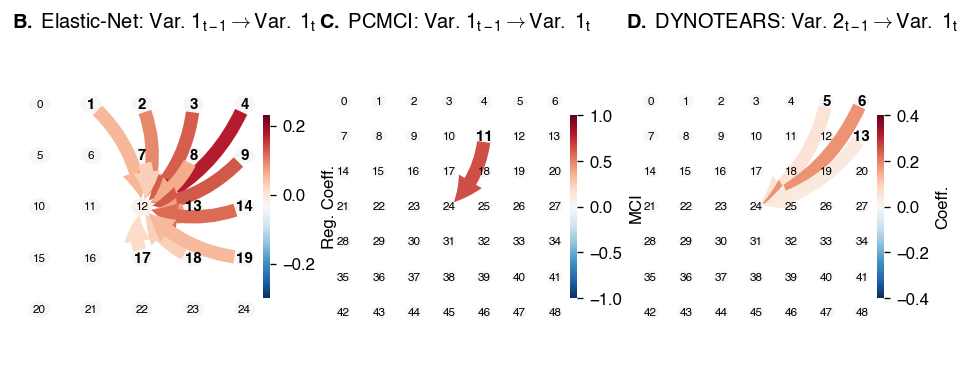

In [175]:
# =========================================================
# Cell 6 — build the exact old-style debug objects + plot B/C/D
# =========================================================

# run Track 2 for the three methods
TRACK_NAME = "Track 2"
STEP_IDX = 0          # first TraCE-ST step
PARENT_TO_PLOT = 1    # Var 1_{t-1} -> Var 1_t

def run_one_track(full_data, params, date_end):
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )
    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)
    return centers, parents, out

track2_runs = {}
base_params_case1 = {
    "granger": params_case1_by_method_and_track["granger"][TRACK_NAME].copy(),
    "pcmci": params_case1_by_method_and_track["pcmci"][TRACK_NAME].copy(),
    "dynotears": params_case1_by_method_and_track["dynotears"][TRACK_NAME].copy(),
}

for method in ["granger", "pcmci", "dynotears"]:
    params_run = copy.deepcopy(base_params_case1[method])
    spec = next(s for s in track_specs if s["name"] == TRACK_NAME)
    event_y, event_x = spec["event"]

    params_run["starting_lat"] = float(event_y)
    params_run["starting_lon"] = float(event_x)
    params_run["montecarlo"] = False
    params_run["verbose"] = False
    params_run["snap_to_grid"] = False
    params_run["averaging_winners"] = True

    centers_run, parents_run, out_run = run_one_track(
        full_data_case1,
        params_run,
        date_end,
    )

    # stash exact run_track debug pieces so the helper uses them
    chosen_sign, chosen_cluster = _winner_to_sign_cluster(out_run["winners"][0] if len(out_run["winners"]) else None)
    params_run["_out_debug_df"] = out_run["debug"][0].copy() if len(out_run["debug"]) else pd.DataFrame()
    params_run["_chosen_sign"] = chosen_sign
    params_run["_chosen_cluster"] = chosen_cluster

    track2_runs[method] = dict(
        params=params_run,
        centers=np.asarray(centers_run, dtype=float),
        parents=np.asarray(parents_run, dtype=int),
        out=out_run,
    )

# exact-style debug objects for the stencil panels
dbg_case1_B = debug_trace_step_from_centers(
    centers_run=track2_runs["granger"]["centers"],
    parents_run=track2_runs["granger"]["parents"],
    params=track2_runs["granger"]["params"],
    full_data_run=full_data_case1,
    date_end=date_end,
    step_idx=0,
    verbose_local=0,
)

dbg_case1_C = debug_trace_step_from_centers(
    centers_run=track2_runs["pcmci"]["centers"],
    parents_run=track2_runs["pcmci"]["parents"],
    params=track2_runs["pcmci"]["params"],
    full_data_run=full_data_case1,
    date_end=date_end,
    step_idx=0,
    verbose_local=0,
)

dbg_case1_D = debug_trace_step_from_centers(
    centers_run=track2_runs["dynotears"]["centers"],
    parents_run=track2_runs["dynotears"]["parents"],
    params=track2_runs["dynotears"]["params"],
    full_data_run=full_data_case1,
    date_end=date_end,
    step_idx=0,
    verbose_local=0,
)

fig = plt.figure(figsize=(9.4, 3.6))
gs = gridspec.GridSpec(1, 3, wspace=0.18)

axB = fig.add_subplot(gs[0, 0])
axC = fig.add_subplot(gs[0, 1])
axD = fig.add_subplot(gs[0, 2])

draw_stencil_panel(
    axB,
    dbg_case1_B,
    None,
    vmin=-0.3, vmax=0.23,
    bar_label="Reg. Coeff.",
    parent=1, child=1,
    highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_B, 1, 1),
)

draw_stencil_panel(
    axC,
    dbg_case1_C,
    None,
    vmin=-1.0, vmax=1.0,
    bar_label="MCI",
    parent=1, child=1,
    highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_C, 1, 1),
)

draw_stencil_panel(
    axD,
    dbg_case1_D,
    None,
    vmin=-0.4, vmax=0.4,
    bar_label="Coeff.",
    parent=2, child=1,
    highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_D, 2, 1),
)

axB.text(0.00, 1.02, r"$\bf{B.}$ Elastic-Net: Var. $1_{t-1}\rightarrow Var.\ 1_t$",
         transform=axB.transAxes, ha="left", va="bottom", fontsize=12)
axC.text(0.00, 1.02, r"$\bf{C.}$ PCMCI: Var. $1_{t-1}\rightarrow Var.\ 1_t$",
         transform=axC.transAxes, ha="left", va="bottom", fontsize=12)
axD.text(0.00, 1.02, r"$\bf{D.}$ DYNOTEARS: Var. $2_{t-1}\rightarrow Var.\ 1_t$",
         transform=axD.transAxes, ha="left", va="bottom", fontsize=12)

plt.show()

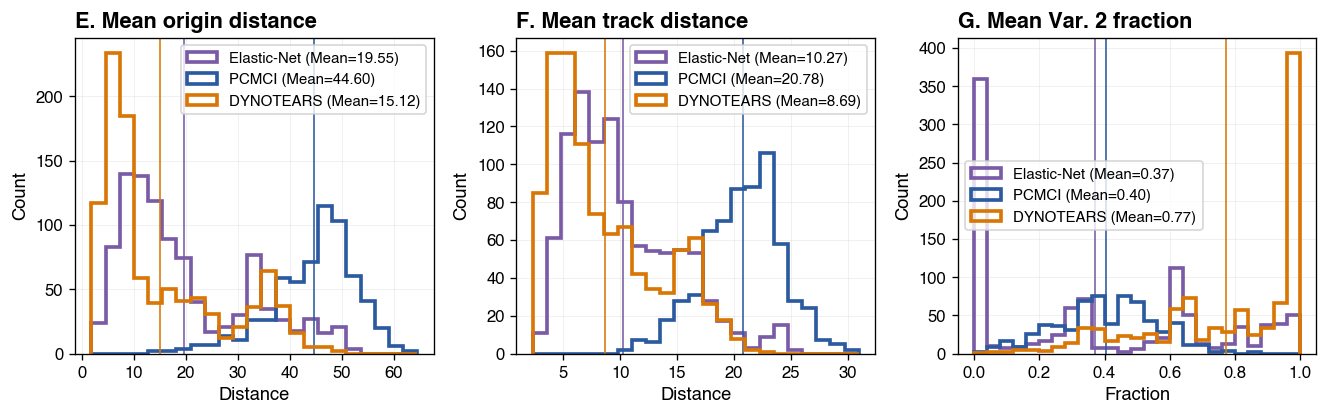

In [176]:
# =========================================================
# E, F, G — histograms across valid runs for the three methods
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

method_order = ["granger", "pcmci", "dynotears"]
label_map = {
    "granger": "Elastic-Net",
    "pcmci": "PCMCI",
    "dynotears": "DYNOTEARS",
}
color_map = {
    "granger": "#7a5ba6",
    "pcmci": "#2c5aa0",
    "dynotears": "#d97706",
}
ls_map = {
    "granger": "solid",
    "pcmci": "solid",
    "dynotears": "solid",
}

metric_specs = [
    ("mean_origin_distance", "E. Mean origin distance", "Distance"),
    ("mean_distance",        "F. Mean track distance",  "Distance"),
    ("mean_parent2_frac",    "G. Mean Var. 2 fraction", "Fraction"),
]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.6))

for ax, (metric_col, title, xlabel) in zip(axes, metric_specs):
    vals_all = pd.to_numeric(df_valid[metric_col], errors="coerce")
    vals_all = vals_all[np.isfinite(vals_all)]

    if len(vals_all) == 0:
        ax.text(0.5, 0.5, f"No valid values for\n{metric_col}", ha="center", va="center")
        ax.set_title(title, loc="left", fontweight="bold")
        continue

    if "frac" in metric_col:
        bins = np.linspace(0, 1, 26)
    else:
        bins = np.linspace(vals_all.min(), vals_all.max(), 24)

    for method in method_order:
        sub = df_valid[df_valid["method"] == method].copy()
        vals = pd.to_numeric(sub[metric_col], errors="coerce")
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue

        ax.hist(
            vals,
            bins=bins,
            histtype="step",
            linewidth=2.2,
            density=False,
            color=color_map[method],
            linestyle=ls_map[method],
            label=f"{label_map[method]} (Mean={np.mean(vals):.2f})",
        )

        ax.axvline(
            np.mean(vals),
            color=color_map[method],
            linestyle=ls_map[method],
            linewidth=1.2,
            alpha=0.8,
        )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.22, linewidth=0.5)
    ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

In [177]:
def plot_panel_A_upper(
    ax,
    *,
    A,
    xs,
    ys,
    T,
    track_specs,
    df_valid,
    df_traj,
    best_rows_case1,
    extent=(50, 200, 25, 175),
    contour_every=3,
    contour_level=0.6,
    n_random_granger=100,
    random_seed=11,
    bg_alpha=0.08,
    bg_lw=0.9,
    fg_lw=2.6,
    box_alpha_fg=0.18,
    box_stride_fg=2,
):
    rng = np.random.default_rng(random_seed)

    # --------------------------------------------------
    # comparable truth window only: t-30 ... t
    # --------------------------------------------------
    truth_start = max(0, T - 31)
    truth_idx = np.arange(truth_start, T, contour_every, dtype=int)

    # --------------------------------------------------
    # 1) prescribed contours only over t-30 ... t
    # --------------------------------------------------
    for t in truth_idx:
        ax.contour(
            xs, ys, A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.55,
            zorder=1,
        )

    # --------------------------------------------------
    # 2) prescribed trajectories + event markers only over t-30 ... t
    # --------------------------------------------------
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        truth_plot = truth[truth_start:T]
        truth_plot_idx = truth_idx - truth_start

        event_y, event_x = spec["event"]

        ax.plot(
            truth_plot[truth_plot_idx, 1],
            truth_plot[truth_plot_idx, 0],
            "--",
            color="black",
            linewidth=1.8,
            zorder=4,
            label="Prescribed track" if k == 1 else None,
        )
        ax.scatter(
            truth_plot[truth_plot_idx, 1],
            truth_plot[truth_plot_idx, 0],
            s=16,
            color="black",
            zorder=5,
        )
        ax.plot(
            event_x, event_y,
            marker="X",
            markersize=11,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )
        ax.text(
            event_x + 16, event_y + 6,
            f"{k}",
            fontsize=12,
            fontweight="bold",
            color="black",
            zorder=11,
        )

    # --------------------------------------------------
    # 3) 100 random valid granger members in background
    #    lines only, no boxes
    # --------------------------------------------------
    granger_valid = df_valid[df_valid["method"] == "granger"].copy()

    if len(granger_valid) > n_random_granger:
        granger_valid = granger_valid.sample(n_random_granger, random_state=random_seed)

    granger_ids = set(granger_valid["trial_id"].tolist())
    sub_granger_bg = df_traj[
        (df_traj["method"] == "granger") &
        (df_traj["trial_id"].isin(granger_ids))
    ].copy()

    for _, r in sub_granger_bg.iterrows():
        centers = _to_array(r["centers_raw"])
        if len(centers) == 0:
            continue

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color="#7a5ba6",
            linewidth=bg_lw,
            alpha=bg_alpha,
            zorder=3,
        )

    # --------------------------------------------------
    # 4) best trajectory for each method in foreground
    #    boxes only for these best tracks
    # --------------------------------------------------
    method_specs = [
     ("granger","Elastic-Net", "#5e2d50"),
     ("pcmci","PCMCI",         "#5f93d1"),
     ("dynotears","DYNOTEARS", "#c98245"),
    ]

    shown_labels = set()

    for spec in track_specs:
        track_name = spec["name"]

        for method_key, method_label, color in method_specs:
            row_best = best_rows_case1[method_key][track_name]

            sub_best = df_traj[
                (df_traj["method"] == method_key) &
                (df_traj["trial_id"] == row_best["trial_id"]) &
                (df_traj["track_name"] == track_name)
            ].copy()

            if len(sub_best) == 0:
                continue

            r = sub_best.iloc[0]
            centers = _to_array(r["centers_raw"])
            if len(centers) == 0:
                continue

            add_boxes(
                ax,
                centers[::box_stride_fg],
                box_size=float(r["box_size"]),
                color=color,
                alpha=box_alpha_fg,
                lw=1.0,
                zorder=6,
            )

            ax.plot(
                centers[:, 1],
                centers[:, 0],
                "-",
                color=color,
                linewidth=fg_lw,
                alpha=0.95,
                zorder=7,
                label=method_label if method_label not in shown_labels else None,
            )

            ax.plot(
                centers[0, 1], centers[0, 0],
                marker="s",
                markersize=5.5,
                color=color,
                zorder=8,
            )
            ax.plot(
                centers[-1, 1], centers[-1, 0],
                marker="*",
                markersize=10.5,
                color=color,
                zorder=9,
            )

            shown_labels.add(method_label)

    # --------------------------------------------------
    # formatting
    # --------------------------------------------------
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.grid(True, alpha=0.20, linewidth=0.5)
    ax.legend(loc="upper left", frameon=True, fontsize=10,ncols=1)

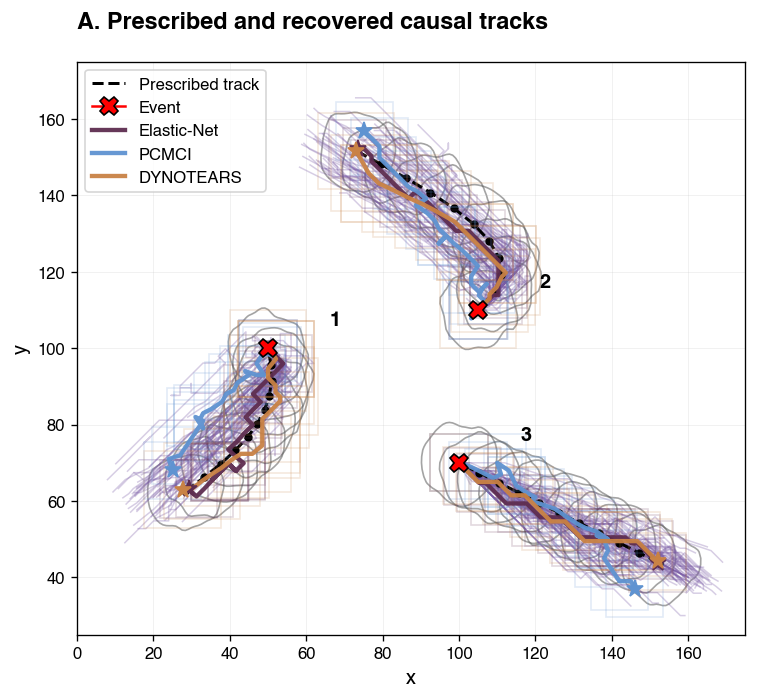

In [178]:
fig, ax = plt.subplots(figsize=(7.6, 6.2))

plot_panel_A_upper(
    ax,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    track_specs=track_specs,
    df_valid=df_valid,
    df_traj=df_traj,
    best_rows_case1=best_rows_case1,
    extent=(0, 175, 25, 175),
    contour_every=3,
    n_random_granger=100,
    random_seed=11,
    bg_alpha=0.3
)

ax.text(
    0.0, 1.05,
    "A. Prescribed and recovered causal tracks",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=14,
    fontweight="bold",
)

plt.show()

In [179]:
import matplotlib as mpl
import matplotlib.font_manager as fm
# ------------------------------------------------------------
# Font setup (Helvetica Regular + Bold)
# ------------------------------------------------------------
font_dir = "/glade/u/home/jhayron/Causality_CaStLe/PaperCausalBTs/Helvetica"

regular_font = os.path.join(font_dir, "Helvetica.ttf")
bold_font = os.path.join(font_dir, "Helvetica-Bold.ttf")

if os.path.exists(regular_font):
    fm.fontManager.addfont(regular_font)

if os.path.exists(bold_font):
    fm.fontManager.addfont(bold_font)

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.weight"] = "regular"

mpl.rcParams.update({
    # --------------------------------------------------
    # FONT FAMILY
    # --------------------------------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # --------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------
    "font.weight": "regular",
    "axes.titleweight": "bold",
    "axes.labelweight": "regular",

    # --------------------------------------------------
    # FONT SIZES (optional but recommended)
    # --------------------------------------------------
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,

    # --------------------------------------------------
    # IMPORTANT: MATH TEXT → match Helvetica
    # --------------------------------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",   # ← THIS fixes the warning

    # --------------------------------------------------
    # PDF / VECTOR EXPORT (VERY IMPORTANT FOR PAPERS)
    # --------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

mpl.rcParams.update({

    # -------------------------
    # FONT FAMILY
    # -------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # -------------------------
    # BASE SIZE (master control)
    # -------------------------
    "font.size": 11,

    # -------------------------
    # TITLES
    # -------------------------
    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    # -------------------------
    # AXIS LABELS
    # -------------------------
    "axes.labelsize": 11,

    # -------------------------
    # TICKS
    # -------------------------
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # -------------------------
    # LEGENDS
    # -------------------------
    "legend.fontsize": 9,

    # -------------------------
    # COLORBAR
    # -------------------------
    "axes.labelweight": "regular",

    # -------------------------
    # MATH TEXT (critical)
    # -------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",

    # -------------------------
    # VECTOR EXPORT
    # -------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [182]:
# ============================================================
# Upper part of Fig. 2 — panels A–G together
# A: prescribed + random Granger bg + best trajectories
# B/C/D: stencils
# E/F/G: histograms
# ============================================================

def make_fig2_upper(
    *,
    A,
    xs,
    ys,
    T,
    track_specs,
    df_valid,
    df_traj,
    best_rows_case1,
    dbg_case1_B,
    dbg_case1_C,
    dbg_case1_D,
):
    fig = plt.figure(figsize=(18, 6))
    gs = gridspec.GridSpec(
        2, 4,
        width_ratios=[1.55, 1.0, 1.0, 1.0],
        height_ratios=[1.0, 1.0],
        wspace=0.22,
        hspace=0.22,
    )

    axA = fig.add_subplot(gs[:, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[0, 2])
    axD = fig.add_subplot(gs[0, 3])

    axE = fig.add_subplot(gs[1, 1])
    axF = fig.add_subplot(gs[1, 2])
    axG = fig.add_subplot(gs[1, 3])

    # --------------------------------------------------------
    # A
    # --------------------------------------------------------
    plot_panel_A_upper(
        axA,
        A=A,
        xs=xs,
        ys=ys,
        T=T,
        track_specs=track_specs,
        df_valid=df_valid,
        df_traj=df_traj,
        best_rows_case1=best_rows_case1,
        extent=(0, 175, 25, 175),
        contour_every=3,
        contour_level=0.6,
        n_random_granger=100,
        random_seed=11,
        bg_alpha=0.2,
        bg_lw=0.9,
        fg_lw=2.6,
        box_alpha_fg=0.18,
        box_stride_fg=2,
    )

    # --------------------------------------------------------
    # B / C / D
    # --------------------------------------------------------
    draw_stencil_panel(
        axB,
        dbg_case1_B,
        None,
        vmin=-0.3, vmax=0.23,
        bar_label="Reg. Coeff.",
        parent=1, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_B, 1, 1),
    )
    
    draw_stencil_panel(
        axC,
        dbg_case1_C,
        None,
        vmin=-1.0, vmax=1.0,
        bar_label="Par. Corr.",
        parent=1, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_C, 1, 1),
    )
    
    draw_stencil_panel(
        axD,
        dbg_case1_D,
        None,
        vmin=-0.4, vmax=0.4,
        bar_label="Reg. Coeff.",
        parent=2, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_D, 2, 1),
    )

    # --------------------------------------------------------
    # E / F / G histograms
    # --------------------------------------------------------
    method_order = ["granger", "pcmci", "dynotears"]
    label_map = {
        "granger": "Elastic-Net",
        "pcmci": "PCMCI",
        "dynotears": "DYNOTEARS",
    }
    color_map = {
        "granger": "#5e2d50",
        "pcmci": "#5f93d1",
        "dynotears": "#c98245",
    }

    hist_specs = [
        (axE, "mean_origin_distance", "E. Mean origin distance", "Distance"),
        (axF, "mean_distance",        "F. Mean track distance",  "Distance"),
        (axG, "mean_parent2_frac",    "G. Mean Var. 2 fraction", "Fraction"),
    ]

    for ax, metric_col, title, xlabel in hist_specs:
        vals_all = pd.to_numeric(df_valid[metric_col], errors="coerce")
        vals_all = vals_all[np.isfinite(vals_all)]

        if "frac" in metric_col:
            bins = np.linspace(0, 1, 26)
        else:
            bins = np.linspace(vals_all.min(), vals_all.max(), 24)

        for method in method_order:
            sub = df_valid[df_valid["method"] == method].copy()
            vals = pd.to_numeric(sub[metric_col], errors="coerce")
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            ax.hist(
                vals,
                bins=bins,
                histtype="step",
                linewidth=2.2,
                density=False,
                color=color_map[method],
                label=f"{label_map[method]}",
            )

            ax.axvline(
                np.median(vals),
                color=color_map[method],
                linewidth=1.2,
                alpha=0.85,
            )

        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.grid(alpha=0.22, linewidth=0.5)
        ax.legend(frameon=True, fontsize=8, loc='upper center')

    # --------------------------------------------------------
    # panel titles
    # --------------------------------------------------------
    axA.set_title(
        "A. Prescribed and recovered tracks",
        loc="left",
        fontsize=15,
        fontweight="bold",
        pad=10,
    )
    
    axB.set_title(
        r"B. Elastic-Net: $Var.\ 1_{t-1}\rightarrow Var.\ 1_t$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=8,
    )
    
    axC.set_title(
        r"C. PCMCI: $Var.\ 1_{t-1}\rightarrow Var.\ 1_t$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=8,
    )
    
    axD.set_title(
        r"D. DYNOTEARS: $Var.\ 2_{t-1}\rightarrow Var.\ 1_t$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=8,
    )

    axE.set_title("E. Mean origin distance", loc="left", fontsize=13, fontweight="bold")
    axF.set_title("F. Mean track distance",  loc="left", fontsize=13, fontweight="bold")
    axG.set_title("G. Mean Var. 2 fraction", loc="left", fontsize=13, fontweight="bold")

    return fig, dict(A=axA, B=axB, C=axC, D=axD, E=axE, F=axF, G=axG)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


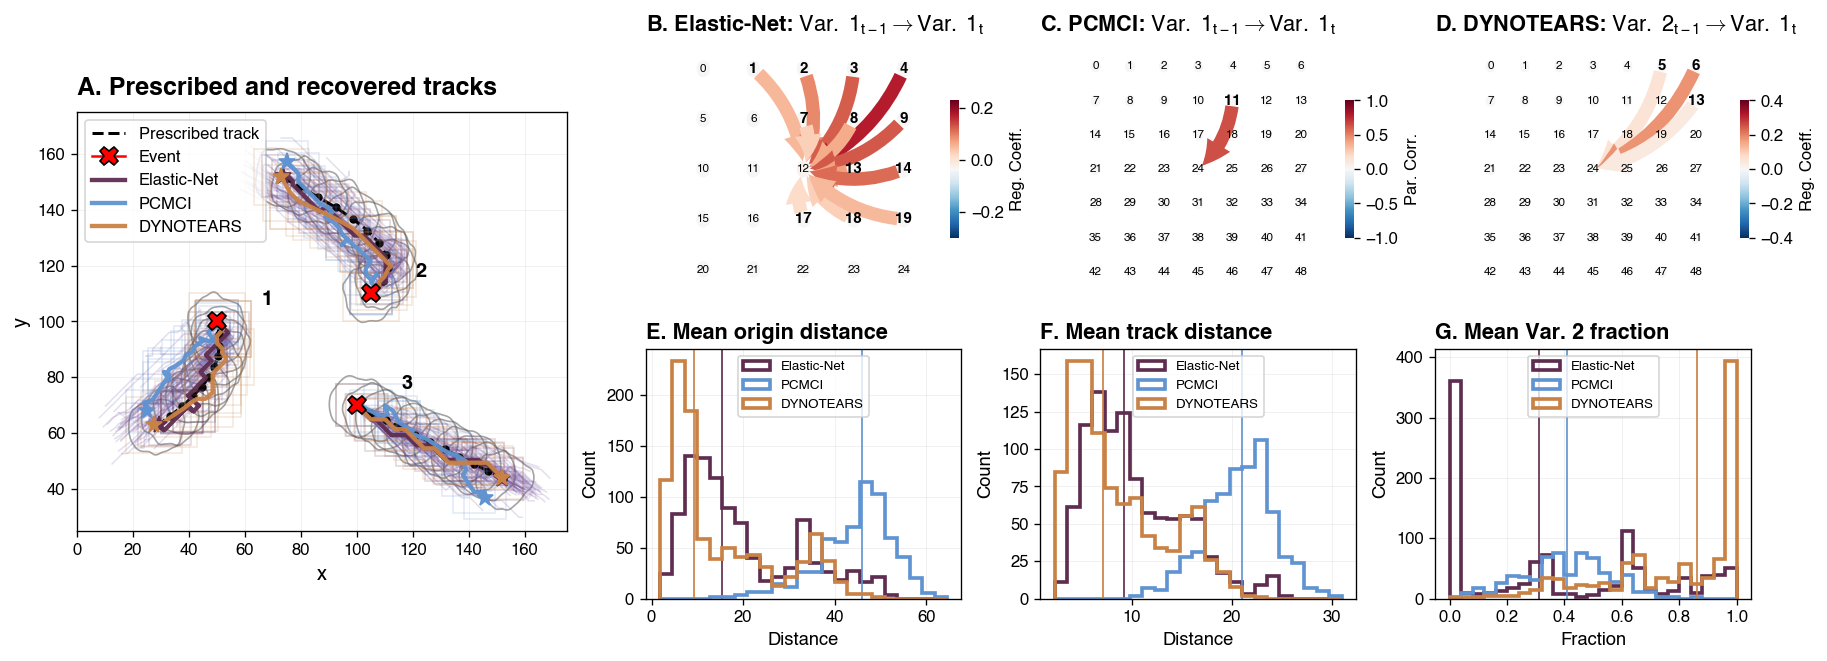

In [184]:
# ============================================================
# Build the whole upper part
# ============================================================

fig_upper, axes_upper = make_fig2_upper(
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    track_specs=track_specs,
    df_valid=df_valid,
    df_traj=df_traj,
    best_rows_case1=best_rows_case1,
    dbg_case1_B=dbg_case1_B,
    dbg_case1_C=dbg_case1_C,
    dbg_case1_D=dbg_case1_D,
)

plt.savefig('fig_synthetic_case1.pdf')

In [185]:
from pypdf import PdfReader, PdfWriter

reader = PdfReader("fig_synthetic_case1.pdf")
writer = PdfWriter()

# crop amounts in PDF points (72 pt = 1 inch)
left_crop   = 120
right_crop  = 80
bottom_crop = 15
top_crop    = 20

for page in reader.pages:
    box = page.mediabox

    x0 = float(box.left) + left_crop
    y0 = float(box.bottom) + bottom_crop
    x1 = float(box.right) - right_crop
    y1 = float(box.top) - top_crop

    page.cropbox.lower_left = (x0, y0)
    page.cropbox.upper_right = (x1, y1)
    page.mediabox.lower_left = (x0, y0)
    page.mediabox.upper_right = (x1, y1)

    writer.add_page(page)

with open("fig_synthetic_case1_cropped.pdf", "wb") as f:
    writer.write(f)

# multivariate part

In [56]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")
    return rows


def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def summarize_table(name, df):
    print(f"{name}: shape={df.shape}")
    if len(df) > 0:
        print(f"  columns={list(df.columns[:12])}" + (" ..." if len(df.columns) > 12 else ""))

In [57]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v4")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v4
Exists: True
Bundles dir exists: True


In [58]:
if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if alphas_csv_final.exists():
    alphas_df = pd.read_csv(alphas_csv_final)
elif alphas_csv_snapshot.exists():
    alphas_df = pd.read_csv(alphas_csv_snapshot)
else:
    alphas_df = pd.DataFrame(load_jsonl(alphas_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("alphas_df", alphas_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

jobs_df: shape=(300, 54)
  columns=['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax'] ...
alphas_df: shape=(1200, 93)
  columns=['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax'] ...
members_df: shape=(36000, 42)
  columns=['member_id', 'ok', 'error', 'n_steps', 'path_length', 'net_displacement', 'mean_step', 'stagnant_frac', 'first_step_parent', 'end_parent', 'frac_parent1', 'frac_parent2'] ...
n bundle npz files: 1200
n bundle json files: 1200

run_metadata:
  seed: 11
  n_trials: 300
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  alpha_mix_grid: [0.2, 0.4, 0.6, 0.8]
  n_total_trials: 300
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 300
  updated_at: 2026-04-05T05:06:07.578911+00:00

run_summary:
  finished_at: 2026-0

In [59]:
if len(jobs_df) > 0:
    if "ok" in jobs_df.columns:
        print("Completed trial rows:", len(jobs_df))
        print("Successful trial rows:", int(jobs_df["ok"].sum()))
        print("Failed trial rows:", int((1 - jobs_df["ok"]).sum()))
    if "trial_id" in jobs_df.columns:
        print("Unique completed trial_ids:", jobs_df["trial_id"].nunique())

if len(alphas_df) > 0:
    print("\nAlpha rows per alpha_mix:")
    if "alpha_mix" in alphas_df.columns:
        print(alphas_df["alpha_mix"].value_counts(dropna=False).sort_index())

if len(members_df) > 0:
    print("\nMember rows:")
    if "trial_id" in members_df.columns:
        print("Unique trial_ids in members_df:", members_df["trial_id"].nunique())
    if "alpha_mix" in members_df.columns:
        print("Unique alpha_mix values in members_df:", sorted(pd.Series(members_df["alpha_mix"]).dropna().unique()))

Completed trial rows: 300
Successful trial rows: 300
Failed trial rows: 0
Unique completed trial_ids: 300

Alpha rows per alpha_mix:
0.2    300
0.4    300
0.6    300
0.8    300
Name: alpha_mix, dtype: int64

Member rows:
Unique trial_ids in members_df: 300
Unique alpha_mix values in members_df: [0.2, 0.4, 0.6, 0.8]


In [60]:
jobs_df.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'n_alpha', 'n_alpha_valid_physical',
       'frac_alpha_valid_physical', 'mean_mae_initial', 'mean_mae_end',
       'mean_mae_step', 'mean_mae_density', 'max_mae_initial', 'max_mae_end',
       'max_mae_step', 'max_mae_density', 'mean_ok_frac', 'min_ok_frac',
       'mean_mean_n_steps', 'min_q25_n_steps', 'mean_mean_net_displacement',
       'mean_mean_path_length', 'mean_mean_stagnant_frac',
       'mean_density_var2_frac', 'mean_step_var2_frac',
       'mean_initial_var2_frac', 'mean_end_var2_frac',
       'corr_alpha_vs_density_var1', 'corr_alpha_vs_step_var1',
       'corr_alpha_vs_end_var1', 'corr_alpha_vs_initial_var1',
       'corr_prescribed_vs_estimated_alpha_end',
      

In [61]:
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    dy = y2d - float(y0)
    dx = x2d - float(x0)
    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def bezier_centers(start, control1, control2, end, T):
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)
    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )
    return centers


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(eps0, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(eps, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
        noise[t] = phi * noise[t - 1] + eps

    return noise


def build_dataarray(var_name, arr, time_coord, ys, xs):
    return xr.DataArray(
        arr[:, None, :, :].astype(np.float32),
        dims=("time", "var", "y", "x"),
        coords={
            "time": time_coord,
            "var": [var_name],
            "y": ys,
            "x": xs,
        },
        name="synthetic",
    )


def build_multivariate_case(
    alpha_mix=0.6,
    T=40,
    N_inject=8,
    tau_mix=1,
    sig_y=10.0,
    sig_x=10.0,
    amp_A=1.0,
    amp_C=1.0,
    phi_A=0.85,
    phi_C=0.85,
    phi_B=0.80,
    sigma_A=0.10,
    sigma_C=0.10,
    sigma_B=0.10,
    clip_to_positive=True,
    seed=GLOBAL_SEED,
):
    time_coord = pd.date_range("2001-01-01", periods=T, freq="D")

    Y_MIN, Y_MAX = 0, 200
    X_MIN, X_MAX = 0, 200
    NY = 121
    NX = 241
    ys = np.linspace(Y_MIN, Y_MAX, NY)
    xs = np.linspace(X_MIN, X_MAX, NX)
    x2d, y2d = np.meshgrid(xs, ys)

    event_y = 100.0
    event_x = 100.0

    centers_A = bezier_centers(
        start=(145.0, 60.0),
        control1=(142.0, 95.0),
        control2=(120.0, 98.0),
        end=(event_y, event_x),
        T=T,
    )
    centers_C = bezier_centers(
        start=(40.0, 150.0),
        control1=(75.0, 148.0),
        control2=(98.0, 118.0),
        end=(event_y, event_x),
        T=T,
    )

    A_clean = np.zeros((T, NY, NX), dtype=np.float32)
    C_clean = np.zeros((T, NY, NX), dtype=np.float32)
    for t in range(T):
        A_clean[t] = gaussian_blob(
            y2d, x2d,
            y0=centers_A[t, 0],
            x0=centers_A[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_A,
        ).astype(np.float32)
        C_clean[t] = gaussian_blob(
            y2d, x2d,
            y0=centers_C[t, 0],
            x0=centers_C[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_C,
        ).astype(np.float32)

    rng_A = np.random.default_rng(seed + 0)
    rng_C = np.random.default_rng(seed + 2)
    noise_A = make_spatiotemporal_ar1_noise(A_clean.shape, phi=phi_A, sigma=sigma_A, rng=rng_A)
    noise_C = make_spatiotemporal_ar1_noise(C_clean.shape, phi=phi_C, sigma=sigma_C, rng=rng_C)

    A = A_clean + noise_A
    C = C_clean + noise_C
    if clip_to_positive:
        A = np.clip(A, 0.0, None)
        C = np.clip(C, 0.0, None)

    t0 = T - int(N_inject)
    if t0 < 0:
        raise ValueError("N_inject too large.")
    if t0 - tau_mix < 0:
        raise ValueError("Need t0 - tau_mix >= 0.")

    rng_B = np.random.default_rng(seed + 1)
    noise_B = make_spatiotemporal_ar1_noise((T, NY, NX), phi=phi_B, sigma=sigma_B, rng=rng_B)
    B = noise_B.copy()

    for t in range(t0, T):
        B[t] = (
            alpha_mix * A_clean[t - tau_mix]
            + (1.0 - alpha_mix) * C_clean[t - tau_mix]
            + noise_B[t]
        )
    if clip_to_positive:
        B = np.clip(B, 0.0, None)

    full_data_A = build_dataarray("A", A, time_coord, ys, xs)
    full_data_B = build_dataarray("B", B, time_coord, ys, xs)
    full_data_C = build_dataarray("C", C, time_coord, ys, xs)

    full_data_run = xr.concat([full_data_A, full_data_B, full_data_C], dim="var")
    full_data_run = full_data_run.rename({"y": "lat", "x": "lon"})
    date_end = str(time_coord[-1].date())

    case = dict(
        full_data_run=full_data_run,
        A=A,
        B=B,
        C=C,
        A_clean=A_clean,
        C_clean=C_clean,
        centers_A=centers_A,
        centers_C=centers_C,
        event=(event_y, event_x),
        xs=xs,
        ys=ys,
        x2d=x2d,
        y2d=y2d,
        time=time_coord,
        T=T,
        date_end=date_end,
        alpha_mix=float(alpha_mix),
        target_parent_fractions={1: float(alpha_mix), 3: float(1.0 - alpha_mix)},
        injection_start_idx=int(t0),
        tau_mix=int(tau_mix),
        N_inject=int(N_inject),
    )
    return case

In [62]:
# ============================================================
# Cell 1 — pick one good alpha=0.2 row and load its bundle
# ============================================================

def bundle_stem_multivar(trial_id, alpha_mix):
    alpha_tag = str(float(alpha_mix)).replace(".", "p")
    return f"trial_{int(trial_id):05d}_alpha_{alpha_tag}"

def load_multivar_bundle(trial_id, alpha_mix, bundles_dir=BUNDLES_DIR):
    stem = bundle_stem_multivar(trial_id, alpha_mix)
    npz_path = bundles_dir / f"{stem}.npz"
    json_path = bundles_dir / f"{stem}.json"

    arrays_npz = np.load(npz_path, allow_pickle=True)
    arrays = {k: arrays_npz[k] for k in arrays_npz.files}
    meta = load_json(json_path)
    return {"arrays": arrays, "meta": meta, "npz_path": npz_path, "json_path": json_path}

alpha_target = 0.6

alpha_sub = alphas_df[np.isclose(pd.to_numeric(alphas_df["alpha_mix"], errors="coerce"), alpha_target)].copy()

# choose a representative row
sort_cols = [c for c in [
    "is_valid_physical",
    "mae_density",
    "mae_end",
    "ok_frac",
] if c in alpha_sub.columns]

ascending = []
for c in sort_cols:
    if c in ["is_valid_physical", "ok_frac"]:
        ascending.append(False)
    else:
        ascending.append(True)

row_H = alpha_sub.sort_values(sort_cols, ascending=ascending).iloc[0].copy()
bundle_H = load_multivar_bundle(int(row_H["trial_id"]), float(row_H["alpha_mix"]))

display(row_H.to_frame().T)

,trial_id,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,prefer_sign,...,valid_mean_stagnant_frac,valid_step_var2_not_dominant,valid_density_var2_not_dominant,valid_any_nontrivial,valid_end_nontrivial,is_valid_physical,estimated_alpha_end,estimated_alpha_density,bundle_npz,bundle_json
26,48,7d,30,5,0.1,2,sum,mean,8.0,both,...,True,True,True,True,True,True,0.6,0.577972,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


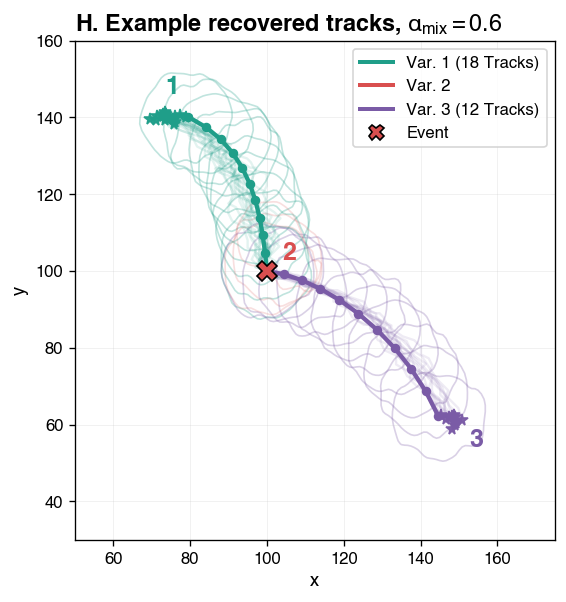

In [63]:
# ============================================================
# Cell 2 — panel H using regenerated synthetic fields
# ============================================================

from matplotlib.lines import Line2D

def plot_panel_H_multivar_example(
    ax,
    *,
    row_alpha,
    bundle,
    contour_every=3,
    contour_level=0.5,
    extent=(55, 175, 30, 160),
    ensemble_alpha=0.12,
):
    # -------------------------
    # regenerate exact synthetic case for contours
    # -------------------------
    alpha_mix = float(row_alpha["alpha_mix"])
    case = build_multivariate_case(
        alpha_mix=alpha_mix,
        T=40,
        N_inject=8,
        tau_mix=1,
        seed=GLOBAL_SEED,
    )

    A = case["A"]
    B = case["B"]
    C = case["C"]
    xs = case["xs"]
    ys = case["ys"]
    T = case["T"]

    truth_A = np.asarray(case["centers_A"], dtype=float)
    truth_C = np.asarray(case["centers_C"], dtype=float)
    event_y, event_x = case["event"]

    # comparable backtracked window
    truth_idx = np.arange(max(0, T - 31), T, contour_every, dtype=int)

    # -------------------------
    # bundle trajectories
    # -------------------------
    arrays = bundle["arrays"]
    centers_all = np.asarray(arrays["centers"], dtype=float)
    parents_all = np.asarray(arrays["parents"], dtype=int)
    lengths = np.asarray(arrays["lengths"], dtype=int)

    # old multivariate colors
    color_var1 = "#1f9e89"   # teal
    color_var2 = "#d94f4f"   # red
    color_var3 = "#7a5ba6"   # purple
    color_map = {1: color_var1, 2: color_var2, 3: color_var3}

    # -------------------------
    # prescribed contours
    # -------------------------
    for t in truth_idx:
        ax.contour(xs, ys, A[t], levels=[contour_level], colors=[color_var1],
                   linewidths=1.0, alpha=0.28, zorder=1)
        ax.contour(xs, ys, B[t], levels=[contour_level], colors=[color_var2],
                   linewidths=1.0, alpha=0.18, zorder=1)
        ax.contour(xs, ys, C[t], levels=[contour_level], colors=[color_var3],
                   linewidths=1.0, alpha=0.28, zorder=1)

    # -------------------------
    # modeled ensemble trajectories
    # color by final parent, same spirit as old panel
    # -------------------------
    n1 = n2 = n3 = 0

    for i in range(len(lengths)):
        L = int(lengths[i])
        if L <= 1:
            continue

        centers = centers_all[i, :L, :]
        parents = parents_all[i, :L]
        p_final = int(parents[-1])

        if p_final == 1:
            n1 += 1
        elif p_final == 2:
            n2 += 1
        elif p_final == 3:
            n3 += 1

        c = color_map.get(p_final, "k")

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color=c,
            linewidth=1.4,
            alpha=ensemble_alpha,
            zorder=3,
        )

        ax.plot(
            centers[0, 1],
            centers[0, 0],
            marker="s",
            markersize=4,
            color=c,
            zorder=4,
            alpha=0.9,
        )
        ax.plot(
            centers[-1, 1],
            centers[-1, 0],
            marker="*",
            markersize=7,
            color=c,
            zorder=5,
            alpha=0.95,
        )

    # -------------------------
    # prescribed trajectories + event
    # -------------------------
    ax.plot(
        truth_A[truth_idx, 1],
        truth_A[truth_idx, 0],
        "-",
        color=color_var1,
        linewidth=2.6,
        zorder=6,
    )
    ax.scatter(
        truth_A[truth_idx, 1],
        truth_A[truth_idx, 0],
        s=22,
        color=color_var1,
        zorder=7,
    )

    ax.plot(
        truth_C[truth_idx, 1],
        truth_C[truth_idx, 0],
        "-",
        color=color_var3,
        linewidth=2.6,
        zorder=6,
    )
    ax.scatter(
        truth_C[truth_idx, 1],
        truth_C[truth_idx, 0],
        s=22,
        color=color_var3,
        zorder=7,
    )

    ax.plot(
        event_x,
        event_y,
        marker="X",
        markersize=12,
        color=color_var2,
        markeredgecolor="black",
        zorder=8,
    )

    # labels 1,2,3
    ax.text(truth_A[truth_idx[0], 1] - 6, truth_A[truth_idx[0], 0] + 6, "1",
            fontsize=15, fontweight="bold", color=color_var1)
    ax.text(event_x + 4, event_y + 3, "2",
            fontsize=15, fontweight="bold", color=color_var2)
    ax.text(truth_C[truth_idx[0], 1] + 8, truth_C[truth_idx[0], 0] - 8, "3",
            fontsize=15, fontweight="bold", color=color_var3)

    ax.set_xlim(*extent[:2])
    ax.set_ylim(*extent[2:])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.20, linewidth=0.5)

    handles = [
        Line2D([0], [0], color=color_var1, lw=2.4, label=f"Var. 1 ({n1} Tracks)"),
        Line2D([0], [0], color=color_var2, lw=2.4, label="Var. 2"),
        Line2D([0], [0], color=color_var3, lw=2.4, label=f"Var. 3 ({n3} Tracks)"),
        Line2D([0], [0], marker="X", color="w", markerfacecolor=color_var2,
               markeredgecolor="black", markersize=9, lw=0, label="Event"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=10)

    ax.set_title(
        rf"H. Example recovered tracks, $\alpha_{{mix}}={alpha_mix:.1f}$",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

fig, ax = plt.subplots(figsize=(5.4, 5.4))
plot_panel_H_multivar_example(
    ax,
    row_alpha=row_H,
    bundle=bundle_H,
    contour_every=3,
    contour_level=0.5,
    extent=(50, 175, 30, 160),
    ensemble_alpha=0.12,
)
plt.show()

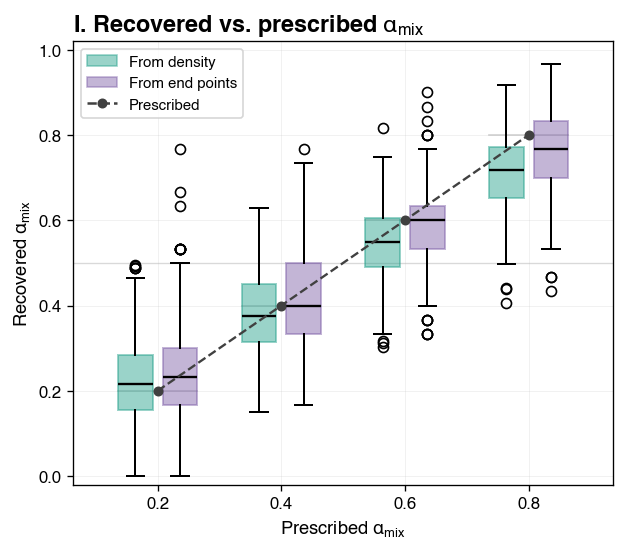

In [64]:
# ============================================================
# Panel I — boxplots of recovered alpha_mix vs prescribed alpha_mix
# using:
#   - density-based estimate: estimated_alpha_density
#   - end-point estimate:     estimated_alpha_end
# ============================================================

def plot_panel_I_alpha_boxplots(
    ax,
    *,
    alphas_df,
    alpha_grid=(0.2, 0.4, 0.6, 0.8),
    density_col="estimated_alpha_density",
    end_col="estimated_alpha_end",
):
    df = alphas_df.copy()

    df["alpha_mix"] = pd.to_numeric(df["alpha_mix"], errors="coerce")
    df[density_col] = pd.to_numeric(df[density_col], errors="coerce")
    df[end_col] = pd.to_numeric(df[end_col], errors="coerce")

    alpha_grid = [float(a) for a in alpha_grid]

    # collect data per prescribed alpha
    dens_data = []
    end_data = []
    valid_alpha = []

    for a in alpha_grid:
        sub = df[np.isclose(df["alpha_mix"], a)].copy()

        vals_d = sub[density_col].to_numpy(dtype=float)
        vals_d = vals_d[np.isfinite(vals_d)]

        vals_e = sub[end_col].to_numpy(dtype=float)
        vals_e = vals_e[np.isfinite(vals_e)]

        if (len(vals_d) == 0) and (len(vals_e) == 0):
            continue

        dens_data.append(vals_d if len(vals_d) else np.array([np.nan]))
        end_data.append(vals_e if len(vals_e) else np.array([np.nan]))
        valid_alpha.append(a)

    x = np.arange(len(valid_alpha), dtype=float)
    pos_d = x - 0.18
    pos_e = x + 0.18

    # colors matched to the figure style
    color_density = "#1f9e89"   # teal
    color_end = "#7a5ba6"       # purple

    bp_d = ax.boxplot(
        dens_data,
        positions=pos_d,
        widths=0.28,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )
    for patch in bp_d["boxes"]:
        patch.set_facecolor(color_density)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color_density)

    bp_e = ax.boxplot(
        end_data,
        positions=pos_e,
        widths=0.28,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )
    for patch in bp_e["boxes"]:
        patch.set_facecolor(color_end)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color_end)

    # prescribed alpha reference
    ax.plot(x, valid_alpha, "o--", color="0.25", linewidth=1.4, markersize=5, zorder=3)

    # 1:1 line feel via diagonal reference
    ax.axhline(0.5, color="0.85", linewidth=0.8, zorder=0)  # subtle guide
    for xi, a in zip(x, valid_alpha):
        ax.plot([xi - 0.32, xi + 0.32], [a, a], color="0.82", linewidth=1.0, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{a:.1f}" for a in valid_alpha])
    ax.set_xlabel(r"Prescribed $\alpha_{mix}$")
    ax.set_ylabel(r"Recovered $\alpha_{mix}$")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.20, linewidth=0.5)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color_density, edgecolor=color_density, alpha=0.45,
                      label=r"From density"),
        plt.Rectangle((0, 0), 1, 1, facecolor=color_end, edgecolor=color_end, alpha=0.45,
                      label=r"From end points"),
        Line2D([0], [0], color="0.25", linestyle="--", marker="o", markersize=5,
               label=r"Prescribed"),
    ]
    ax.legend(handles=handles, frameon=True, fontsize=9, loc="upper left")

    ax.set_title(
        r"I. Recovered vs. prescribed $\alpha_{mix}$",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )


# ------------------------------------------------------------
# draw panel I alone
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.8, 4.8))
plot_panel_I_alpha_boxplots(
    ax,
    alphas_df=alphas_df,
    alpha_grid=(0.2, 0.4, 0.6, 0.8),
    density_col="estimated_alpha_density",
    end_col="estimated_alpha_end",
)
plt.show()

In [65]:
# ============================================================
# Cell 1 — aggregate density maps across ALL ensembles
# for alpha_mix = 0.2 and 0.8, for parent Var 1 and Var 3
# ============================================================

def collect_density_maps_all_ensembles(alphas_df, *, alpha_values=(0.2, 0.8)):
    out = {}

    for alpha_target in alpha_values:
        sub = alphas_df[np.isclose(pd.to_numeric(alphas_df["alpha_mix"], errors="coerce"), float(alpha_target))].copy()

        dens1_sum = None
        dens3_sum = None
        xs_ref = None
        ys_ref = None
        n_trials = 0

        for _, row in sub.iterrows():
            bundle_npz = row.get("bundle_npz", None)
            if pd.isna(bundle_npz) or bundle_npz is None:
                continue

            bundle = load_multivar_bundle(int(row["trial_id"]), float(row["alpha_mix"]))
            arr = bundle["arrays"]

            dens1 = np.asarray(arr["density_parent1"], dtype=float)
            dens3 = np.asarray(arr["density_parent3"], dtype=float)
            xs = np.asarray(arr["xs"], dtype=float)
            ys = np.asarray(arr["ys"], dtype=float)

            if dens1_sum is None:
                dens1_sum = np.zeros_like(dens1, dtype=float)
                dens3_sum = np.zeros_like(dens3, dtype=float)
                xs_ref = xs.copy()
                ys_ref = ys.copy()

            dens1_sum += dens1
            dens3_sum += dens3
            n_trials += 1

        case = build_multivariate_case(alpha_mix=float(alpha_target), T=40, N_inject=8, tau_mix=1, seed=GLOBAL_SEED)

        out[float(alpha_target)] = dict(
            density_var1=dens1_sum,
            density_var3=dens3_sum,
            xs=xs_ref if xs_ref is not None else case["xs"],
            ys=ys_ref if ys_ref is not None else case["ys"],
            case=case,
            n_trials=n_trials,
        )

    return out


density_maps_multi = collect_density_maps_all_ensembles(
    alphas_df,
    alpha_values=(0.2, 0.8),
)

for a in [0.2, 0.8]:
    print(
        f"alpha={a}:",
        "n_trials =", density_maps_multi[a]["n_trials"],
        "| shape var1 =", None if density_maps_multi[a]["density_var1"] is None else density_maps_multi[a]["density_var1"].shape,
        "| shape var3 =", None if density_maps_multi[a]["density_var3"] is None else density_maps_multi[a]["density_var3"].shape,
    )

alpha=0.2: n_trials = 300 | shape var1 = (121, 241) | shape var3 = (121, 241)
alpha=0.8: n_trials = 300 | shape var1 = (121, 241) | shape var3 = (121, 241)


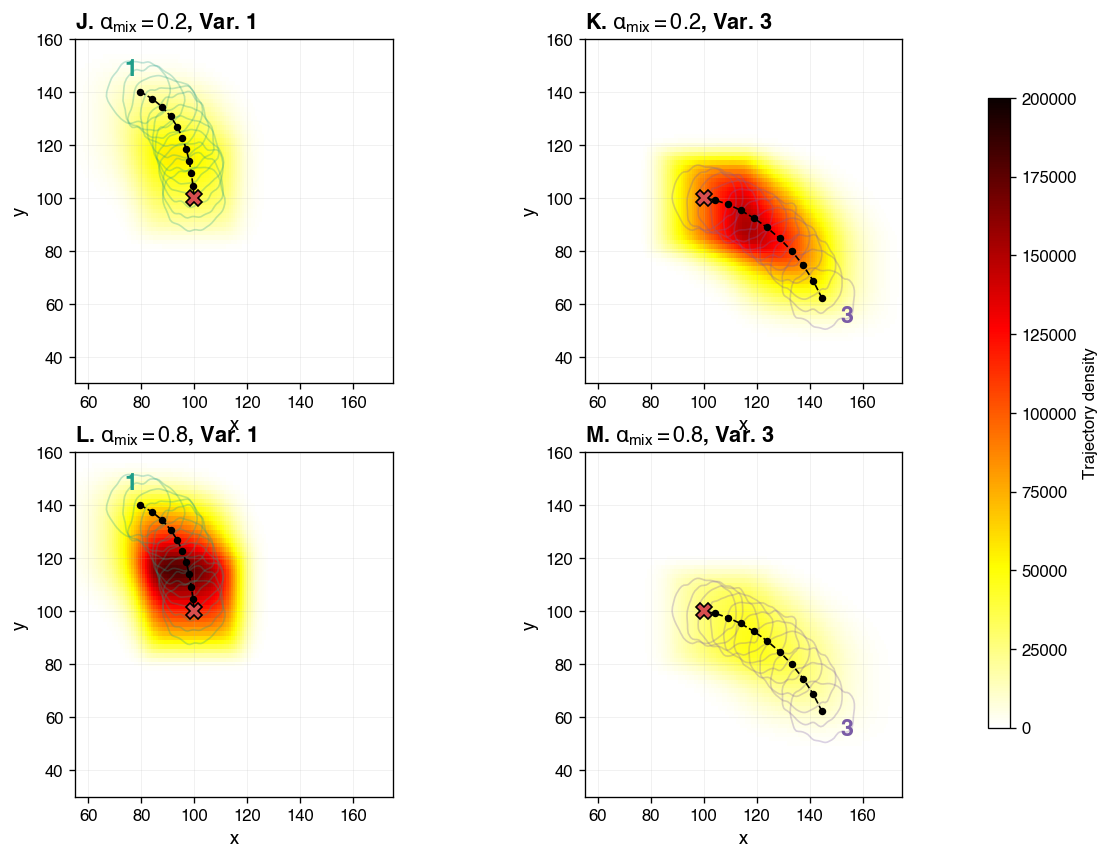

In [66]:
# ============================================================
# Cell 2 — plot J/K/L/M
# J: alpha=0.2, Var 1
# K: alpha=0.2, Var 3
# L: alpha=0.8, Var 1
# M: alpha=0.8, Var 3
# ============================================================

def plot_density_panel_multivar(
    ax,
    *,
    density,
    case,
    xs,
    ys,
    var_key,            # "A" or "C"
    var_label,          # "Var. 1" or "Var. 3"
    alpha_mix,
    panel_label,
    extent=(55, 175, 30, 160),
    contour_every=3,
    contour_level=0.5,
    cmap="magma_r",
    vmin=0.0,
    vmax=None,
    add_colorbar=False,
    bar_label="Trajectory density",
):
    truth_A = np.asarray(case["centers_A"], dtype=float)
    truth_C = np.asarray(case["centers_C"], dtype=float)
    event_y, event_x = case["event"]
    T = int(case["T"])

    truth_idx = np.arange(max(0, T - 31), T, contour_every, dtype=int)

    if var_key == "A":
        field = np.asarray(case["A"], dtype=float)
        truth = truth_A
        contour_color = "#1f9e89"
        text_color = "#1f9e89"
    elif var_key == "C":
        field = np.asarray(case["C"], dtype=float)
        truth = truth_C
        contour_color = "#7a5ba6"
        text_color = "#7a5ba6"
    else:
        raise ValueError("var_key must be 'A' or 'C'")

    pcm = ax.pcolormesh(
        xs, ys, density,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        zorder=1,
        rasterized=True,
    )

    # prescribed blobs / contours
    for t in truth_idx:
        ax.contour(
            xs, ys, field[t],
            levels=[contour_level],
            colors=[contour_color],
            linewidths=1.0,
            alpha=0.28,
            zorder=2,
        )

    # prescribed trajectory
    ax.plot(
        truth[truth_idx, 1],
        truth[truth_idx, 0],
        "--",
        color="black",
        linewidth=1.0,
        zorder=4,
    )
    ax.scatter(
        truth[truth_idx, 1],
        truth[truth_idx, 0],
        s=12,
        color="black",
        zorder=5,
    )

    # event
    ax.plot(
        event_x, event_y,
        marker="X",
        markersize=10,
        color="#d94f4f",
        markeredgecolor="black",
        zorder=6,
    )

    # little track id annotation
    if var_key == "A":
        ax.text(truth[truth_idx[0], 1] - 6, truth[truth_idx[0], 0] + 6, "1",
                fontsize=14, fontweight="bold", color=text_color, zorder=7)
    else:
        ax.text(truth[truth_idx[0], 1] + 7, truth[truth_idx[0], 0] - 9, "3",
                fontsize=14, fontweight="bold", color=text_color, zorder=7)

    ax.set_xlim(*extent[:2])
    ax.set_ylim(*extent[2:])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.20, linewidth=0.5)

    ax.set_title(
        rf"{panel_label}. $\alpha_{{mix}}={alpha_mix:.1f}$, {var_label}",
        loc="left",
        fontsize=13,
        fontweight="bold",
    )

    if add_colorbar:
        cax = inset_axes(
            ax,
            width="4.5%",
            height="55%",
            loc="center left",
            bbox_to_anchor=(1.04, 0.0, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        cb = mpl.colorbar.ColorbarBase(
            cax,
            cmap=mpl.colormaps.get_cmap(cmap),
            norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
            orientation="vertical",
        )
        cb.ax.tick_params(labelsize=9)
        cb.set_label(bar_label, fontsize=9)
        cb.outline.set_visible(False)
        for spine in cax.spines.values():
            spine.set_visible(False)

    return pcm


# common vmax across all four maps
vmax_candidates = []
for a in [0.2, 0.8]:
    for key in ["density_var1", "density_var3"]:
        arr = density_maps_multi[a][key]
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            vmax_candidates.append(np.percentile(arr, 99.0))

common_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
common_vmax = 200000


fig = plt.figure(figsize=(10.2, 8.2))
gs = gridspec.GridSpec(2, 2, wspace=0.16, hspace=0.20)

axJ = fig.add_subplot(gs[0, 0])
axK = fig.add_subplot(gs[0, 1])
axL = fig.add_subplot(gs[1, 0])
axM = fig.add_subplot(gs[1, 1])

plot_density_panel_multivar(
    axJ,
    density=density_maps_multi[0.2]["density_var1"],
    case=density_maps_multi[0.2]["case"],
    xs=density_maps_multi[0.2]["xs"],
    ys=density_maps_multi[0.2]["ys"],
    var_key="A",
    var_label="Var. 1",
    alpha_mix=0.2,
    panel_label="J",
    extent=(55, 175, 30, 160),
    vmin=0.0,
    vmax=common_vmax,
    add_colorbar=False,
    cmap = "hot_r"
)

plot_density_panel_multivar(
    axK,
    density=density_maps_multi[0.2]["density_var3"],
    case=density_maps_multi[0.2]["case"],
    xs=density_maps_multi[0.2]["xs"],
    ys=density_maps_multi[0.2]["ys"],
    var_key="C",
    var_label="Var. 3",
    alpha_mix=0.2,
    panel_label="K",
    extent=(55, 175, 30, 160),
    vmin=0.0,
    vmax=common_vmax,
    add_colorbar=False,
    cmap = "hot_r"
)

plot_density_panel_multivar(
    axL,
    density=density_maps_multi[0.8]["density_var1"],
    case=density_maps_multi[0.8]["case"],
    xs=density_maps_multi[0.8]["xs"],
    ys=density_maps_multi[0.8]["ys"],
    var_key="A",
    var_label="Var. 1",
    alpha_mix=0.8,
    panel_label="L",
    extent=(55, 175, 30, 160),
    vmin=0.0,
    vmax=common_vmax,
    add_colorbar=False,
    cmap = "hot_r"
)

pcm_last = plot_density_panel_multivar(
    axM,
    density=density_maps_multi[0.8]["density_var3"],
    case=density_maps_multi[0.8]["case"],
    xs=density_maps_multi[0.8]["xs"],
    ys=density_maps_multi[0.8]["ys"],
    var_key="C",
    var_label="Var. 3",
    alpha_mix=0.8,
    panel_label="M",
    extent=(55, 175, 30, 160),
    vmin=0.0,
    vmax=common_vmax,
    add_colorbar=False,
    cmap = "hot_r"
)

# one shared colorbar
cax = fig.add_axes([0.92, 0.18, 0.018, 0.64])
cb = fig.colorbar(pcm_last, cax=cax, orientation="vertical")
cb.set_label("Trajectory density", fontsize=10)

plt.show()

In [105]:
def make_fig2_lower(
    *,
    row_H,
    bundle_H,
    alphas_df,
    density_maps_multi,
):
    fig = plt.figure(figsize=(15, 5.), constrained_layout=False)

    gs_lo_outer = fig.add_gridspec(
        1, 3,
        width_ratios=[1.18, 1.38, 1.54],
        left=0.045,
        right=0.95,
        top=0.91,
        bottom=0.1,
        wspace=0.18,
    )

    axH = fig.add_subplot(gs_lo_outer[0, 0])
    axI = fig.add_subplot(gs_lo_outer[0, 1])

    gs_maps = gs_lo_outer[0, 2].subgridspec(
        2, 3,
        width_ratios=[1.0, 1.0, 0.10],
        height_ratios=[1.0, 1.0],
        wspace=0.18,
        hspace=0.22,
    )

    axJ = fig.add_subplot(gs_maps[0, 0])
    axK = fig.add_subplot(gs_maps[0, 1])
    axL = fig.add_subplot(gs_maps[1, 0])
    axM = fig.add_subplot(gs_maps[1, 1])
    cax = fig.add_subplot(gs_maps[:, 2])

    plot_panel_H_multivar_example(
        axH,
        row_alpha=row_H,
        bundle=bundle_H,
        contour_every=3,
        contour_level=0.5,
        extent=(50, 175, 30, 160),
        ensemble_alpha=0.12,
    )

    plot_panel_I_alpha_boxplots(
        axI,
        alphas_df=alphas_df,
        alpha_grid=(0.2, 0.4, 0.6, 0.8),
        density_col="estimated_alpha_density",
        end_col="estimated_alpha_end",
    )

    axI.set_box_aspect(0.9)

    common_vmax = 200000

    plot_density_panel_multivar(
        axJ,
        density=density_maps_multi[0.2]["density_var1"],
        case=density_maps_multi[0.2]["case"],
        xs=density_maps_multi[0.2]["xs"],
        ys=density_maps_multi[0.2]["ys"],
        var_key="A",
        var_label="Var. 1",
        alpha_mix=0.2,
        panel_label="C",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="BuPu",
    )

    plot_density_panel_multivar(
        axK,
        density=density_maps_multi[0.2]["density_var3"],
        case=density_maps_multi[0.2]["case"],
        xs=density_maps_multi[0.2]["xs"],
        ys=density_maps_multi[0.2]["ys"],
        var_key="C",
        var_label="Var. 3",
        alpha_mix=0.2,
        panel_label="D",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="BuPu",
    )

    plot_density_panel_multivar(
        axL,
        density=density_maps_multi[0.8]["density_var1"],
        case=density_maps_multi[0.8]["case"],
        xs=density_maps_multi[0.8]["xs"],
        ys=density_maps_multi[0.8]["ys"],
        var_key="A",
        var_label="Var. 1",
        alpha_mix=0.8,
        panel_label="E",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="BuPu",
    )

    pcm_last = plot_density_panel_multivar(
        axM,
        density=density_maps_multi[0.8]["density_var3"],
        case=density_maps_multi[0.8]["case"],
        xs=density_maps_multi[0.8]["xs"],
        ys=density_maps_multi[0.8]["ys"],
        var_key="C",
        var_label="Var. 3",
        alpha_mix=0.8,
        panel_label="F",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="BuPu",
    )

    for ax in [axJ, axK]:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    for ax in [axK, axM]:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax_inner = inset_axes(
        cax,
        width="100%",
        height="50%",
        loc="center",
        borderpad=0,
    )
    cax.axis("off")

    cb = fig.colorbar(pcm_last, cax=cax_inner, orientation="vertical")
    cb.set_label("Trajectory density")
    cb.ax.tick_params(labelsize=9)

    axH.set_title(
        r"A. Example recovered tracks, $\alpha_{mix}=0.6$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=5,
    )
    axI.set_title(
        r"B. Recovered vs. prescribed $\alpha_{mix}$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=5,
    )

    for ax in [axH, axI, axJ, axK, axL, axM]:
        ax.tick_params(labelsize=9)

    return fig, dict(H=axH, I=axI, J=axJ, K=axK, L=axL, M=axM)

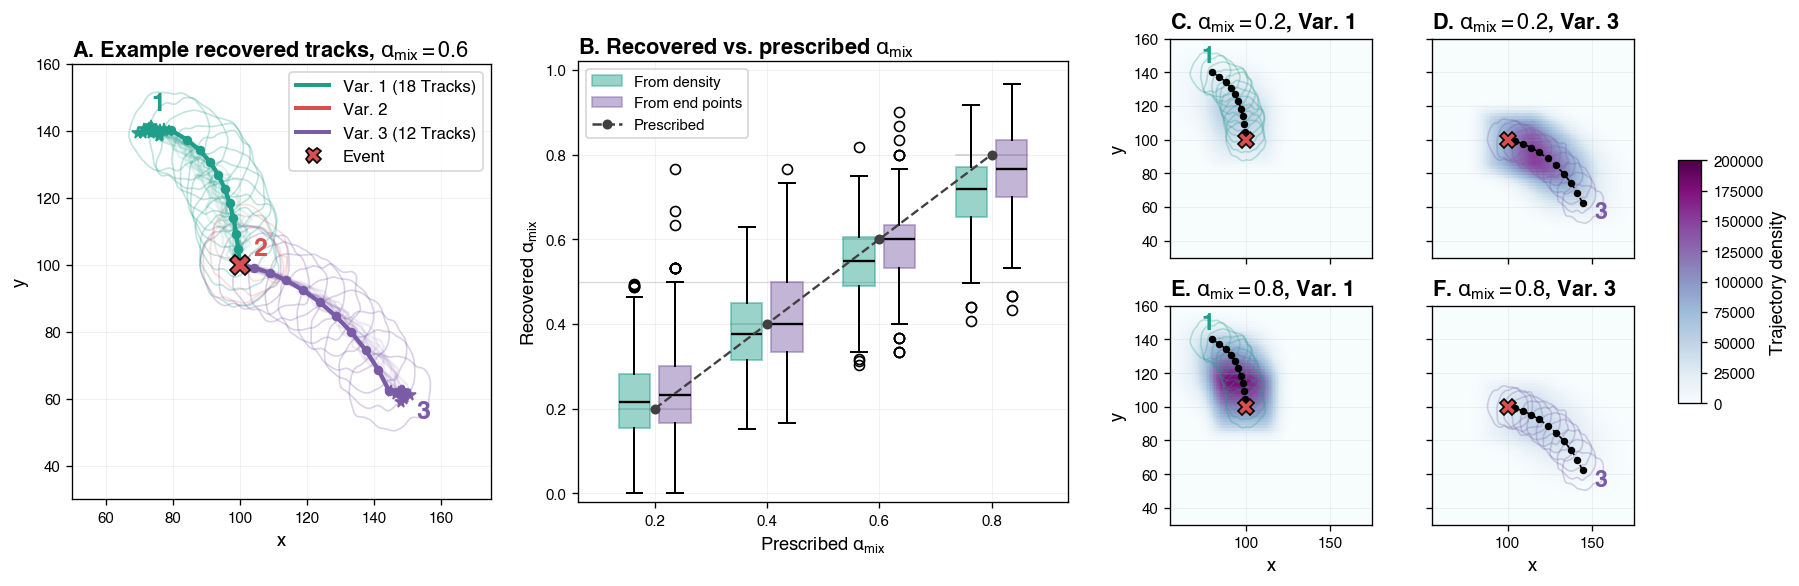

In [106]:
fig2_lower, axes2_lower = make_fig2_lower(
    row_H=row_H,
    bundle_H=bundle_H,
    alphas_df=alphas_df,
    density_maps_multi=density_maps_multi,
)

fig2_lower.savefig("fig_synthetic_case2.pdf")
plt.show()

# Join everything

In [67]:
from matplotlib.lines import Line2D

def make_fig2_full(
    *,
    # ---- upper part inputs ----
    A,
    xs,
    ys,
    T,
    track_specs,
    df_valid,
    df_traj,
    best_rows_case1,
    dbg_case1_B,
    dbg_case1_C,
    dbg_case1_D,
    # ---- lower part inputs ----
    row_H,
    bundle_H,
    alphas_df,
    density_maps_multi,
):
    fig = plt.figure(figsize=(18.5, 14), constrained_layout=False)

    # ========================================================
    # OUTER LAYOUT
    # ========================================================
    outer = fig.add_gridspec(
        4, 1,
        height_ratios=[0.035, 1.0, 0.12, 1.12],
        hspace=0.08,
    )

    # --------------------------------------------------------
    # section headers
    # --------------------------------------------------------
    ax_header_top = fig.add_subplot(outer[0, 0])
    ax_header_bot = fig.add_subplot(outer[2, 0])

    for axh in [ax_header_top, ax_header_bot]:
        axh.axis("off")

    ax_header_top.text(
        0.5, 1.2,
        "Synthetic univariate cases: track recovery under confounding",
        ha="center", va="center",
        fontweight="bold", fontsize = 15,
        transform=ax_header_top.transAxes,
    )

    ax_header_bot.text(
        0.5, 0.35,
        "Synthetic multivariate case: track recovery and causal attribution",
        ha="center", va="center",
        fontweight="bold", fontsize = 15,
        transform=ax_header_bot.transAxes,
    )

    # ========================================================
    # UPPER BLOCK
    # Make B-D larger and closer to E-G
    # ========================================================
    gs_up = outer[1, 0].subgridspec(
        2, 4,
        width_ratios=[1.42, 1.12, 1.12, 1.12],
        height_ratios=[1.05, 0.95],
        wspace=0.18,
        hspace=0.08,
    )

    axA = fig.add_subplot(gs_up[:, 0])
    axB = fig.add_subplot(gs_up[0, 1])
    axC = fig.add_subplot(gs_up[0, 2])
    axD = fig.add_subplot(gs_up[0, 3])

    axE = fig.add_subplot(gs_up[1, 1])
    axF = fig.add_subplot(gs_up[1, 2])
    axG = fig.add_subplot(gs_up[1, 3])

    # ========================================================
    # LOWER BLOCK
    # ========================================================
    gs_lo_outer = outer[3, 0].subgridspec(
        1, 3,
        width_ratios=[1.18, 1.38, 1.54],
        wspace=0.18,
    )
    
    axH = fig.add_subplot(gs_lo_outer[0, 0])
    axI = fig.add_subplot(gs_lo_outer[0, 1])
    
    gs_maps = gs_lo_outer[0, 2].subgridspec(
        2, 3,
        width_ratios=[1.0, 1.0, 0.10],
        height_ratios=[1.0, 1.0],
        wspace=0.18,
        hspace=0.22,
    )
    
    axJ = fig.add_subplot(gs_maps[0, 0])
    axK = fig.add_subplot(gs_maps[0, 1])
    axL = fig.add_subplot(gs_maps[1, 0])
    axM = fig.add_subplot(gs_maps[1, 1])
    cax = fig.add_subplot(gs_maps[:, 2])

    # ========================================================
    # A — prescribed + random granger bg + best trajectories
    # ========================================================
    plot_panel_A_upper(
        axA,
        A=A,
        xs=xs,
        ys=ys,
        T=T,
        track_specs=track_specs,
        df_valid=df_valid,
        df_traj=df_traj,
        best_rows_case1=best_rows_case1,
        extent=(0, 175, 25, 175),
        contour_every=3,
        contour_level=0.6,
        n_random_granger=100,
        random_seed=11,
        bg_alpha=0.2,
        bg_lw=0.9,
        fg_lw=2.6,
        box_alpha_fg=0.18,
        box_stride_fg=2,
    )

    # ========================================================
    # B / C / D — stencils
    # ========================================================
    draw_stencil_panel(
        axB,
        dbg_case1_B,
        None,
        vmin=-0.3, vmax=0.23,
        bar_label="Reg. Coeff.",
        parent=1, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_B, 1, 1),
    )

    draw_stencil_panel(
        axC,
        dbg_case1_C,
        None,
        vmin=-1.0, vmax=1.0,
        bar_label="MCI",
        parent=1, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_C, 1, 1),
    )

    draw_stencil_panel(
        axD,
        dbg_case1_D,
        None,
        vmin=-0.4, vmax=0.4,
        bar_label="Coeff.",
        parent=2, child=1,
        highlight_nodes=get_plotted_source_nodes_from_block(dbg_case1_D, 2, 1),
    )

    # ========================================================
    # E / F / G — histograms
    # ========================================================
    method_order = ["granger", "pcmci", "dynotears"]
    label_map = {
        "granger": "Elastic-Net",
        "pcmci": "PCMCI",
        "dynotears": "DYNOTEARS",
    }
    color_map = {
        "granger": "#7a5ba6",
        "pcmci": "#2c5aa0",
        "dynotears": "#d97706",
    }

    hist_specs = [
        (axE, "mean_origin_distance", "E. Mean origin distance", "Distance"),
        (axF, "mean_distance",        "F. Mean track distance",  "Distance"),
        (axG, "mean_parent2_frac",    "G. Mean Var. 2 fraction", "Fraction"),
    ]

    for ax, metric_col, title, xlabel in hist_specs:
        vals_all = pd.to_numeric(df_valid[metric_col], errors="coerce")
        vals_all = vals_all[np.isfinite(vals_all)]

        if "frac" in metric_col:
            bins = np.linspace(0, 1, 26)
        else:
            bins = np.linspace(vals_all.min(), vals_all.max(), 24)

        for method in method_order:
            sub = df_valid[df_valid["method"] == method].copy()
            vals = pd.to_numeric(sub[metric_col], errors="coerce")
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            ax.hist(
                vals,
                bins=bins,
                histtype="step",
                linewidth=2.0,
                density=False,
                color=color_map[method],
                label=label_map[method],
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(alpha=0.22, linewidth=0.5)
        ax.legend(frameon=True, loc="upper center")
        ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=4)

    # make the histograms use space better
    for ax in [axE, axF, axG]:
        ax.set_box_aspect(0.62)

    # ========================================================
    # H — example multivariate recovered tracks
    # ========================================================
    plot_panel_H_multivar_example(
        axH,
        row_alpha=row_H,
        bundle=bundle_H,
        contour_every=3,
        contour_level=0.5,
        extent=(50, 175, 30, 160),
        ensemble_alpha=0.12,
    )

    # ========================================================
    # I — alpha_mix boxplots
    # ========================================================
    plot_panel_I_alpha_boxplots(
        axI,
        alphas_df=alphas_df,
        alpha_grid=(0.2, 0.4, 0.6, 0.8),
        density_col="estimated_alpha_density",
        end_col="estimated_alpha_end",
    )

    # make I slightly more compact vertically while keeping it wide
    axI.set_box_aspect(0.9)

    # ========================================================
    # J / K / L / M — density maps across all ensembles
    # ========================================================
    vmax_candidates = []
    for a in [0.2, 0.8]:
        for key in ["density_var1", "density_var3"]:
            arr = np.asarray(density_maps_multi[a][key], dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vmax_candidates.append(np.percentile(arr, 99.0))

    common_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    common_vmax = 200000

    plot_density_panel_multivar(
        axJ,
        density=density_maps_multi[0.2]["density_var1"],
        case=density_maps_multi[0.2]["case"],
        xs=density_maps_multi[0.2]["xs"],
        ys=density_maps_multi[0.2]["ys"],
        var_key="A",
        var_label="Var. 1",
        alpha_mix=0.2,
        panel_label="J",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="hot_r",
    )

    plot_density_panel_multivar(
        axK,
        density=density_maps_multi[0.2]["density_var3"],
        case=density_maps_multi[0.2]["case"],
        xs=density_maps_multi[0.2]["xs"],
        ys=density_maps_multi[0.2]["ys"],
        var_key="C",
        var_label="Var. 3",
        alpha_mix=0.2,
        panel_label="K",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="hot_r",
    )

    plot_density_panel_multivar(
        axL,
        density=density_maps_multi[0.8]["density_var1"],
        case=density_maps_multi[0.8]["case"],
        xs=density_maps_multi[0.8]["xs"],
        ys=density_maps_multi[0.8]["ys"],
        var_key="A",
        var_label="Var. 1",
        alpha_mix=0.8,
        panel_label="L",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="hot_r",
    )

    pcm_last = plot_density_panel_multivar(
        axM,
        density=density_maps_multi[0.8]["density_var3"],
        case=density_maps_multi[0.8]["case"],
        xs=density_maps_multi[0.8]["xs"],
        ys=density_maps_multi[0.8]["ys"],
        var_key="C",
        var_label="Var. 3",
        alpha_mix=0.8,
        panel_label="M",
        extent=(55, 175, 30, 160),
        vmin=0.0,
        vmax=common_vmax,
        add_colorbar=False,
        cmap="hot_r",
    )
    # --- remove redundant labels for J–M ---
    
    # Top row → remove x labels + tick labels
    for ax in [axJ, axK]:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    
    # Right column → remove y labels + tick labels
    for ax in [axK, axM]:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    # ========================================================
    # shared colorbar for J/K/L/M
    # place it close to K/M without huge empty strip
    # ========================================================
    # shared colorbar for J/K/L/M
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    cax_inner = inset_axes(
        cax,
        width="100%",
        height="50%",   # smaller vertical span
        loc="center",
        borderpad=0,
    )
    cax.axis("off")
    
    cb = fig.colorbar(pcm_last, cax=cax_inner, orientation="vertical")
    cb.set_label("Trajectory density")
    cb.ax.tick_params(labelsize=9)

    # ========================================================
    # panel titles
    # ========================================================
    axA.set_title(
        "A. Prescribed and recovered tracks",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=8,
    )

    axB.set_title(
        r"B. Elastic-Net ($Var\,1(t-1) \to Var\,1(t)$)",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=5,
    )

    axC.set_title(
        r"C. PCMCI ($Var\,1(t-1) \to Var\,1(t)$)",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=5,
    )

    axD.set_title(
        r"D. DYNOTEARS ($Var\,2(t-1) \to Var\,1(t)$)",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=5,
    )

    axH.set_title(
        r"H. Example recovered tracks, $\alpha_{mix}=0.6$",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=5,
    )

    axI.set_title(
        r"I. Recovered vs. prescribed $\alpha_{mix}$",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=5,
    )

    # slightly unify tick label sizes
    for ax in [axA, axE, axF, axG, axH, axI, axJ, axK, axL, axM]:
        ax.tick_params(labelsize=9)

    return fig, dict(
        A=axA, B=axB, C=axC, D=axD, E=axE, F=axF, G=axG,
        H=axH, I=axI, J=axJ, K=axK, L=axL, M=axM,
    )

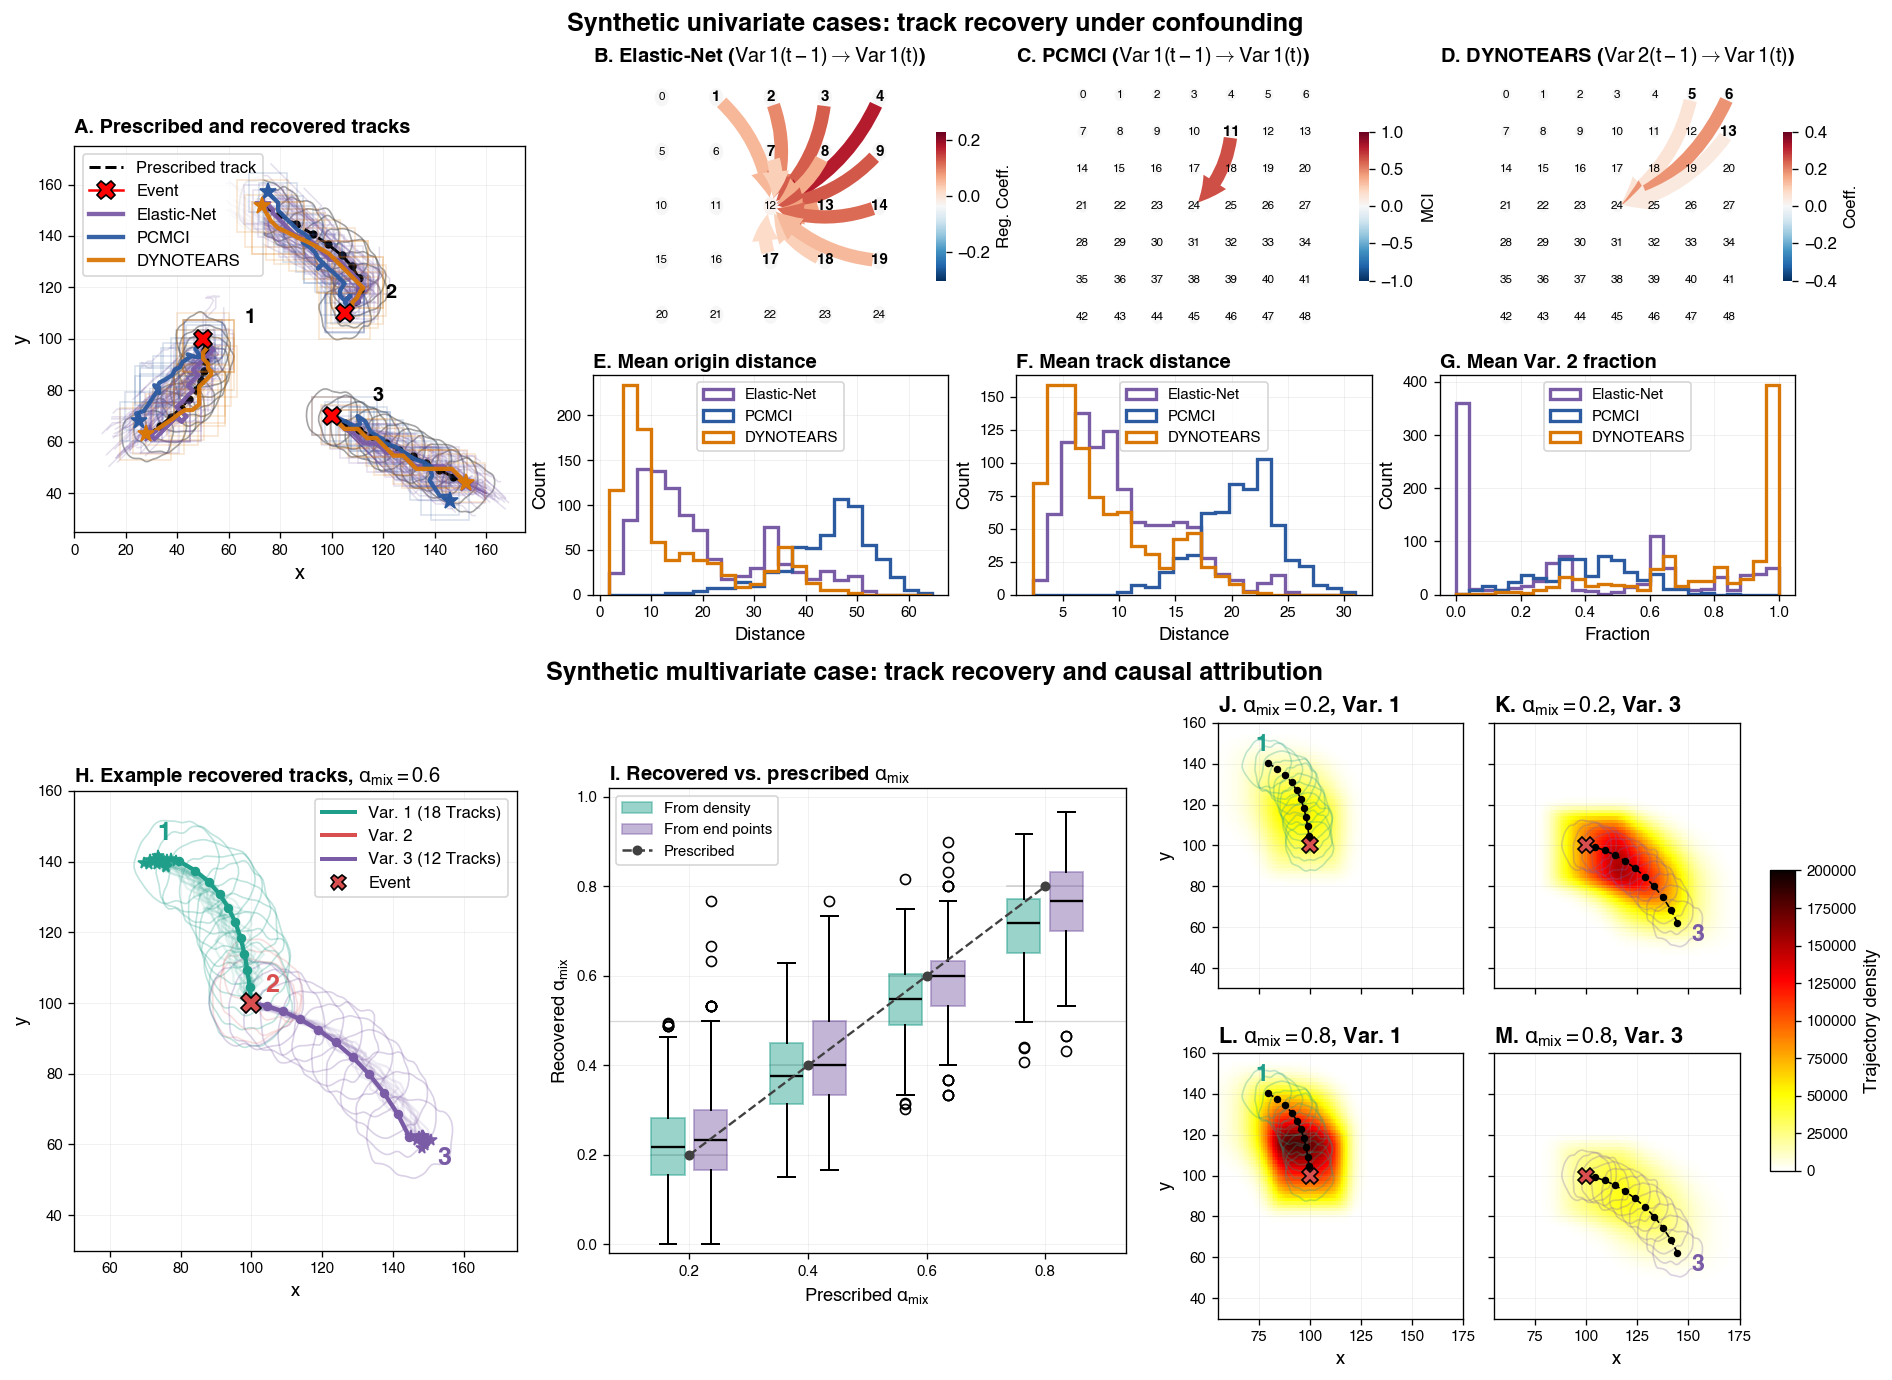

In [68]:

# ------------------------------------------------------------
# Build and show final A–M figure
# ------------------------------------------------------------
fig_final, axes_final = make_fig2_full(
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    track_specs=track_specs,
    df_valid=df_valid,
    df_traj=df_traj,
    best_rows_case1=best_rows_case1,
    dbg_case1_B=dbg_case1_B,
    dbg_case1_C=dbg_case1_C,
    dbg_case1_D=dbg_case1_D,
    row_H=row_H,
    bundle_H=bundle_H,
    alphas_df=alphas_df,
    density_maps_multi=density_maps_multi,
)

plt.show()

# optional save
# fig_final.savefig("fig2_syntheticcases.pdf")

In [44]:
from pypdf import PdfReader, PdfWriter

reader = PdfReader("fig2_syntheticcases.pdf")
writer = PdfWriter()

# crop amounts in PDF points (72 pt = 1 inch)
left_crop   = 120
right_crop  = 80
bottom_crop = 80
top_crop    = 105

for page in reader.pages:
    box = page.mediabox

    x0 = float(box.left) + left_crop
    y0 = float(box.bottom) + bottom_crop
    x1 = float(box.right) - right_crop
    y1 = float(box.top) - top_crop

    page.cropbox.lower_left = (x0, y0)
    page.cropbox.upper_right = (x1, y1)
    page.mediabox.lower_left = (x0, y0)
    page.mediabox.upper_right = (x1, y1)

    writer.add_page(page)

with open("fig2_syntheticcases_cropped.pdf", "wb") as f:
    writer.write(f)